# This is the Python Notebook that uses ESTIMATE by MD Anderson to compute the tumor purity for each spot.

### Import the packages

In [1]:
library(Seurat)
library(estimate)
library(patchwork)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




### Change to the correct directory and load the data

In [2]:
base_dir <- "/scratch/hhuan40/Spatial-MetScore"
raw_dir <- file.path(base_dir, "data", "raw", "Samples")
main_out_dir <- file.path(base_dir, "data", "processed", "tumor_purity_estimate")

sample_names <- list.dirs(raw_dir, full.names = FALSE, recursive = FALSE)

print(sample_names)

 [1] "PT-10A"     "PT-10B"     "PT-10C"     "PT-10D"     "PT-11A"    
 [6] "PT-11B"     "PT-11C"     "PT-11D"     "PT-12A"     "PT-12B"    
[11] "PT-12C"     "PT-12D"     "PT-13A"     "PT-13B"     "PT-13C"    
[16] "PT-13D"     "PT-13E"     "PT-13_PRI2" "PT-13_PRI3" "PT-1A"     
[21] "PT-1C"      "PT-2A"      "PT-2B"      "PT-2C"      "PT-3A"     
[26] "PT-3B"      "PT-3C"      "PT-3_PRI2"  "PT-4A"      "PT-4B"     
[31] "PT-4C"      "PT-4D"      "PT-5A"      "PT-5B"      "PT-5C"     
[36] "PT-6A"      "PT-6B"      "PT-6C"      "PT-6D"      "PT-6_PRI2" 
[41] "PT-6_PRI3"  "PT-7A"      "PT-7B"      "PT-7C"      "PT-7D"     
[46] "PT-8A"      "PT-8B"      "PT-8C"      "PT-8D"      "PT-8_PRI2" 
[51] "PT-9A"      "PT-9B"      "PT-9C"      "PT-9D"     


### Single Sample Heatmaps (PT-1A)

Dealing with: PT-1A

Normalizing layer: counts



[1] "Merged dataset includes 9969 genes (443 mismatched)."
[1] "1 gene set: StromalSignature  overlap= 136"
[1] "2 gene set: ImmuneSignature  overlap= 140"


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Done analyzing. Go to /scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate to check the results.



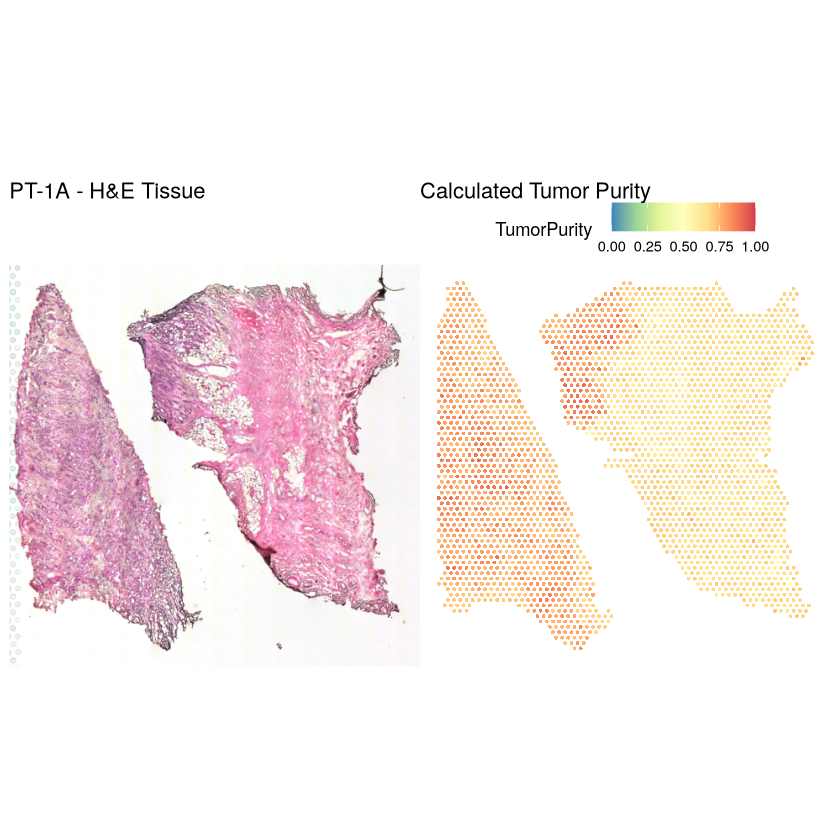

In [8]:
sample_id <- "PT-1A"  


base_dir <- "/scratch/hhuan40/Spatial-MetScore"
raw_dir <- file.path(base_dir, "data", "raw", "Samples", sample_id)
out_dir <- file.path(base_dir, "data", "processed", "tumor_purity_estimate")

# make a new directory for the output if it doesn't exist
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

message("Dealing with: ", sample_id)

seurat_obj <- Load10X_Spatial(data.dir = raw_dir)
seurat_obj <- NormalizeData(seurat_obj)

expr_mat <- as.matrix(GetAssayData(seurat_obj, assay = "Spatial", layer = "data"))

# set temporary file paths for ESTIMATE input and output
mat_file <- file.path(out_dir, paste0(sample_id, "_matrix.txt"))
common_file <- file.path(out_dir, paste0(sample_id, "_common.gct"))
score_file <- file.path(out_dir, paste0(sample_id, "_estimate_scores.gct"))

# output the expression matrix to a tab-delimited text file
write.table(expr_mat, file = mat_file, sep = "\t", quote = FALSE)

# ESTIMATE 
filterCommonGenes(input.f = mat_file, output.f = common_file, id = "GeneSymbol")
estimateScore(input.ds = common_file, output.ds = score_file, platform = "illumina")

# Conversion Tumor Purity and add to Seurat
scores <- read.table(score_file, skip = 2, header = TRUE, row.names = 1)
scores_t <- as.data.frame(t(scores[, -1])) 

seurat_obj$StromalScore <- scores_t$StromalScore
seurat_obj$ImmuneScore <- scores_t$ImmuneScore
seurat_obj$ESTIMATEScore <- scores_t$ESTIMATEScore

# Apply the purity conversion formula.
seurat_obj$TumorPurity <- cos(0.6049872018 + 0.0001467884 * seurat_obj$ESTIMATEScore)

plot_he <- SpatialDimPlot(seurat_obj, alpha = c(0, 0)) + 
  NoLegend() + 
  ggtitle(paste(sample_id, "- H&E Tissue"))

plot_purity <- SpatialFeaturePlot(seurat_obj, features = "TumorPurity", image.alpha = 0) + 
  ggtitle("Calculated Tumor Purity") +
  scale_fill_distiller(palette = "Spectral", limits = c(0, 1))

# patchwork
final_plot <- plot_he | plot_purity

print(final_plot)

ggsave(filename = file.path(out_dir, paste0(sample_id, "_purity_map.png")), 
       plot = final_plot, width = 12, height = 5)

saveRDS(seurat_obj, file = file.path(out_dir, paste0(sample_id, "_processed.rds")))

message("Done analyzing. Go to ", out_dir, " to check the results.")

### All samples tumor purity heatmaps (feature scale)

In [7]:
for (sample_id in sample_names) {
  message(sprintf("========================================"))
  message(sprintf("Now dealing: %s", sample_id))
  
  # create a dedicated output directory for each sample
  sample_out_dir <- file.path(main_out_dir, sample_id)
  if (!dir.exists(sample_out_dir)) {
    dir.create(sample_out_dir, recursive = TRUE)
  }
  
  # load the Seurat object for the current sample
  sample_raw_dir <- file.path(raw_dir, sample_id)
  seurat_obj <- Load10X_Spatial(data.dir = sample_raw_dir)
  seurat_obj <- NormalizeData(seurat_obj)
  
  # extract the expression matrix for the current sample
  expr_mat <- as.matrix(GetAssayData(seurat_obj, assay = "Spatial", layer = "data"))
  
  # setting
  mat_file <- file.path(sample_out_dir, paste0(sample_id, "_matrix.txt"))
  common_file <- file.path(sample_out_dir, paste0(sample_id, "_common.gct"))
  score_file <- file.path(sample_out_dir, paste0(sample_id, "_estimate_scores.gct"))
  rds_file <- file.path(sample_out_dir, paste0(sample_id, "_processed.rds"))
  plot_file <- file.path(sample_out_dir, paste0(sample_id, "_purity_map.png"))
  
  # Export expression matrix
  write.table(expr_mat, file = mat_file, sep = "\t", quote = FALSE)
  
  # Runnign ESTIMATE algorithm
  filterCommonGenes(input.f = mat_file, output.f = common_file, id = "GeneSymbol")
  estimateScore(input.ds = common_file, output.ds = score_file, platform = "illumina")
  
  # Conversion Tumor Purity and add to Seurat
  scores <- read.table(score_file, skip = 2, header = TRUE, row.names = 1)
  scores_t <- as.data.frame(t(scores[, -1])) 
  
  seurat_obj$StromalScore <- scores_t$StromalScore
  seurat_obj$ImmuneScore <- scores_t$ImmuneScore
  seurat_obj$ESTIMATEScore <- scores_t$ESTIMATEScore
  seurat_obj$TumorPurity <- cos(0.6049872018 + 0.0001467884 * seurat_obj$ESTIMATEScore)
  
  # Draw the plot
  plot_he <- SpatialDimPlot(seurat_obj, alpha = c(0, 0)) + 
    NoLegend() + 
    ggtitle(paste(sample_id, "- H&E Tissue"))
  
  plot_purity <- SpatialFeaturePlot(seurat_obj, features = "TumorPurity", image.alpha = 0, pt.size.factor = 1.2) + 
    ggtitle("Calculated Tumor Purity")
  
  final_plot <- plot_he | plot_purity
  
  
  # Save the results
  ggsave(filename = plot_file, plot = final_plot, width = 12, height = 5)
  saveRDS(seurat_obj, file = rds_file)
  
  message(sprintf("Sample %s processing completed! Files saved to: %s", sample_id, sample_out_dir))
}


Now dealing: PT-13_PRI2

Normalizing layer: counts



[1] "Merged dataset includes 9969 genes (443 mismatched)."
[1] "1 gene set: StromalSignature  overlap= 136"
[1] "2 gene set: ImmuneSignature  overlap= 140"


Sample PT-13_PRI2 processing completed! Files saved to: /scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate/PT-13_PRI2


Now dealing: PT-13_PRI3

Normalizing layer: counts



[1] "Merged dataset includes 9969 genes (443 mismatched)."
[1] "1 gene set: StromalSignature  overlap= 136"
[1] "2 gene set: ImmuneSignature  overlap= 140"


Sample PT-13_PRI3 processing completed! Files saved to: /scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate/PT-13_PRI3


Now dealing: PT-1A

Normalizing layer: counts



...

Sample PT-9B processing completed! Files saved to: /scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate/PT-9B


Now dealing: PT-9C

Normalizing layer: counts



[1] "Merged dataset includes 9969 genes (443 mismatched)."
[1] "1 gene set: StromalSignature  overlap= 136"
[1] "2 gene set: ImmuneSignature  overlap= 140"


Sample PT-9C processing completed! Files saved to: /scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate/PT-9C


Now dealing: PT-9D

Normalizing layer: counts



[1] "Merged dataset includes 9969 genes (443 mismatched)."
[1] "1 gene set: StromalSignature  overlap= 136"
[1] "2 gene set: ImmuneSignature  overlap= 140"


Sample PT-9D processing completed! Files saved to: /scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate/PT-9D



### All samples tumor, immune, and stromal heatmaps (0-1)

In [4]:
for (sample_id in sample_names) {
  base_dir <- "/scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate"
  rds_path <- file.path(base_dir, sample_id, paste0(sample_id, "_processed.rds"))
  
  if (!file.exists(rds_path)) {
    next
  }
  
  seurat_obj <- readRDS(rds_path)
  
  # 1. H&E Image
  plot_he <- SpatialDimPlot(seurat_obj, alpha = 0) + 
    NoLegend() + 
    ggtitle("H&E Tissue") +
    theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 16))

  # 2. Tumor Purity
  plot_purity <- suppressMessages(
    SpatialFeaturePlot(seurat_obj, features = "TumorPurity", image.alpha = 0) + 
    scale_fill_distiller(palette = "RdYlBu", direction = -1, limits = c(0, 1)) +
    ggtitle("Tumor Purity (Absolute %)") +
    theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 16))
  )
  
  # 3. Immune Score
  plot_immune <- suppressMessages(
    SpatialFeaturePlot(seurat_obj, features = "ImmuneScore", image.alpha = 0) + 
    scale_fill_distiller(palette = "RdYlBu", direction = -1) +
    ggtitle("Immune Score (Enrichment)") +
    theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 16))
  )
  
  # 4. Stromal Score
  plot_stromal <- suppressMessages(
    SpatialFeaturePlot(seurat_obj, features = "StromalScore", image.alpha = 0) + 
    scale_fill_distiller(palette = "RdYlBu", direction = -1) +
    ggtitle("Stromal Score (Enrichment)") +
    theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 16))
  )
  
  # combine
  combined_plot <- plot_he | plot_purity | plot_immune | plot_stromal
  
  plot_out_path <- file.path(base_dir, sample_id, paste0(sample_id, "_all3.png"))
  ggsave(plot_out_path, plot = combined_plot, width = 24, height = 6, dpi = 300)
}

print("done!")

[1] "done!"


## Tumor Purity Histograms (per sample) 

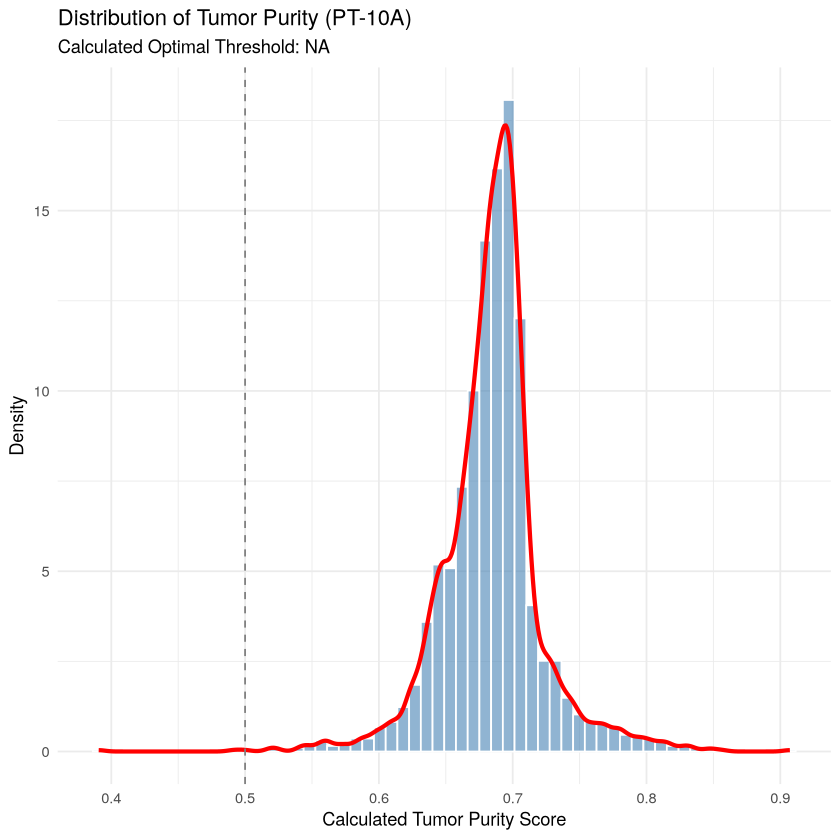

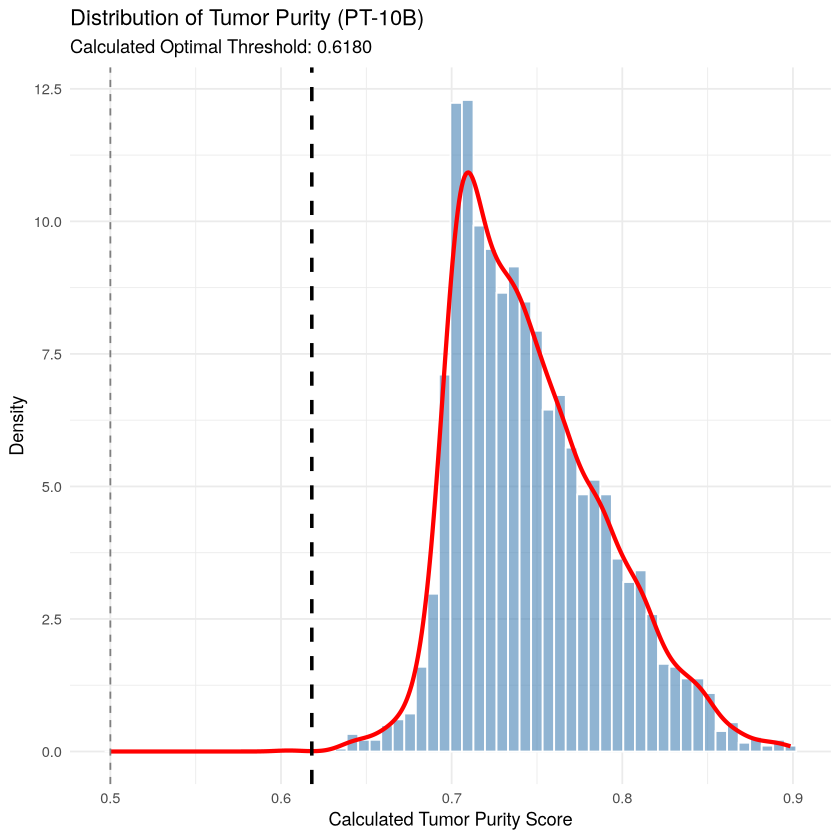

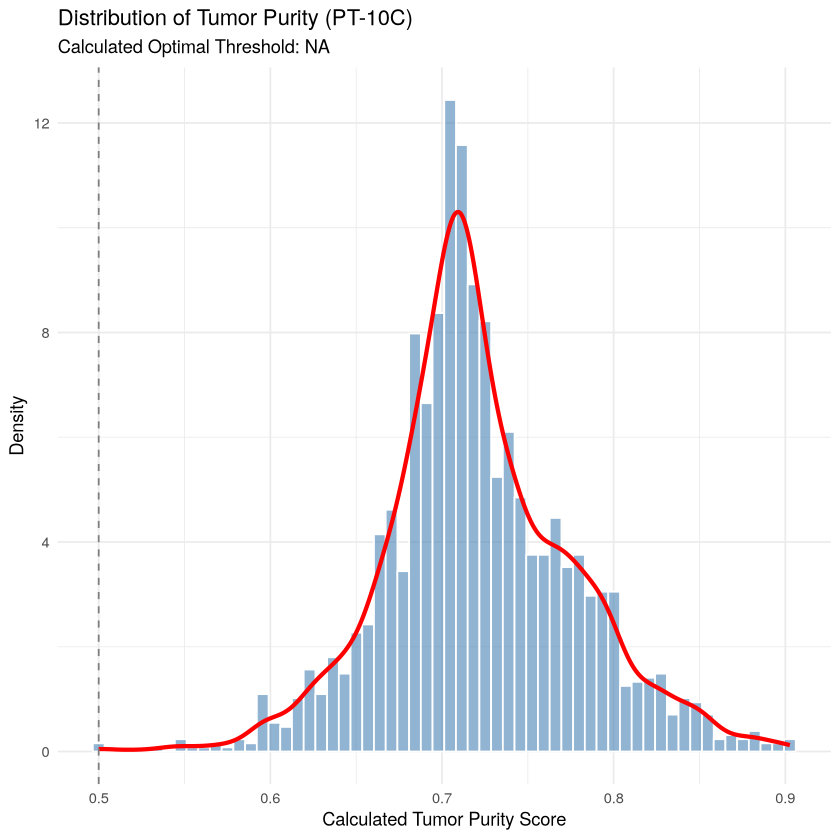

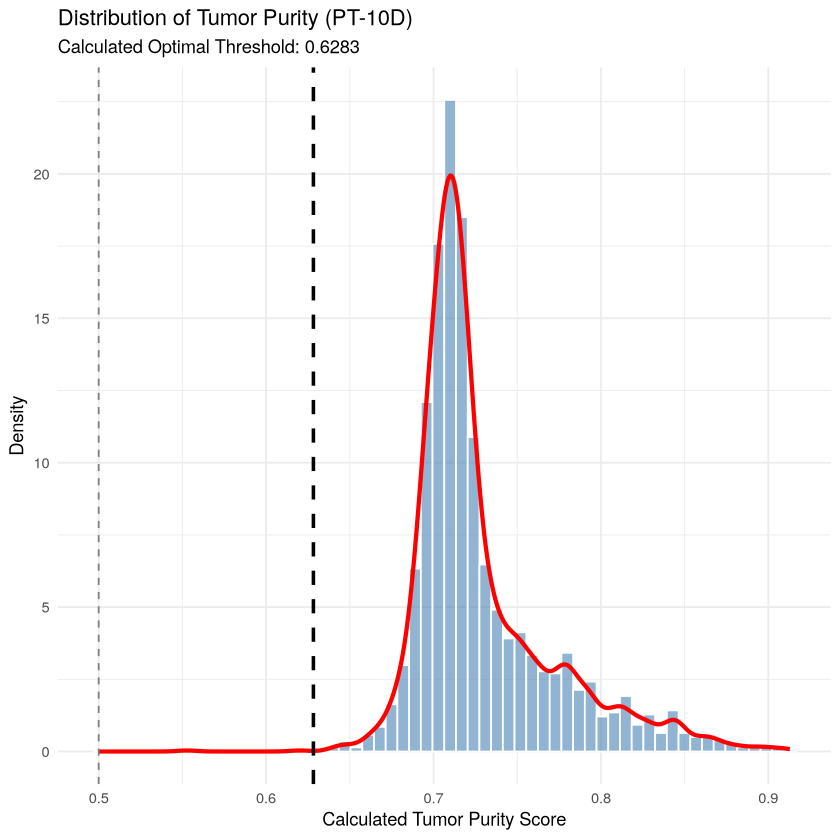

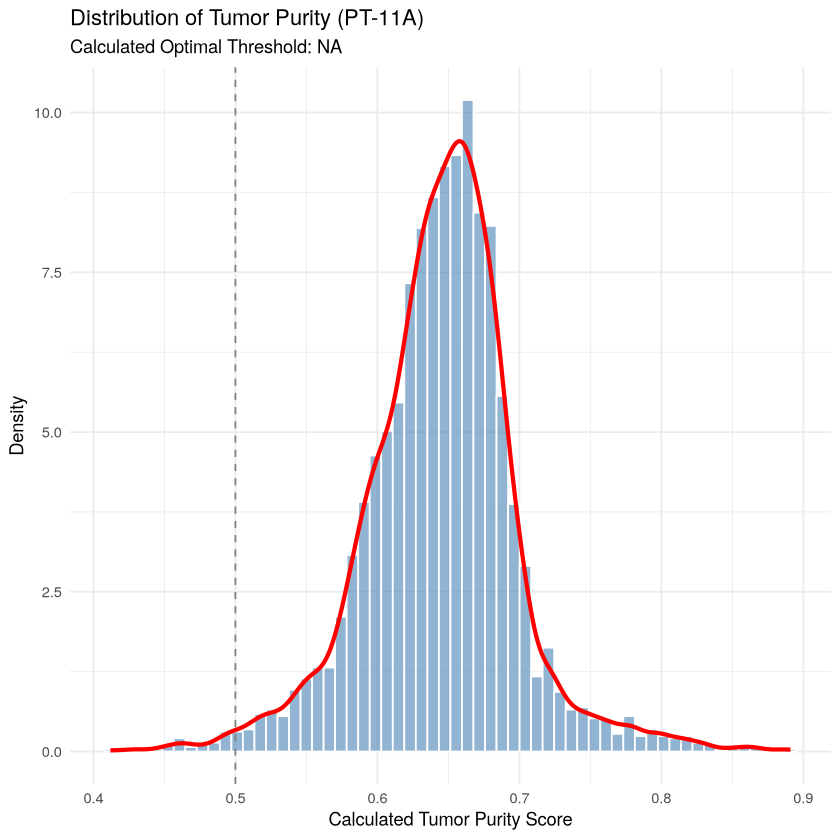

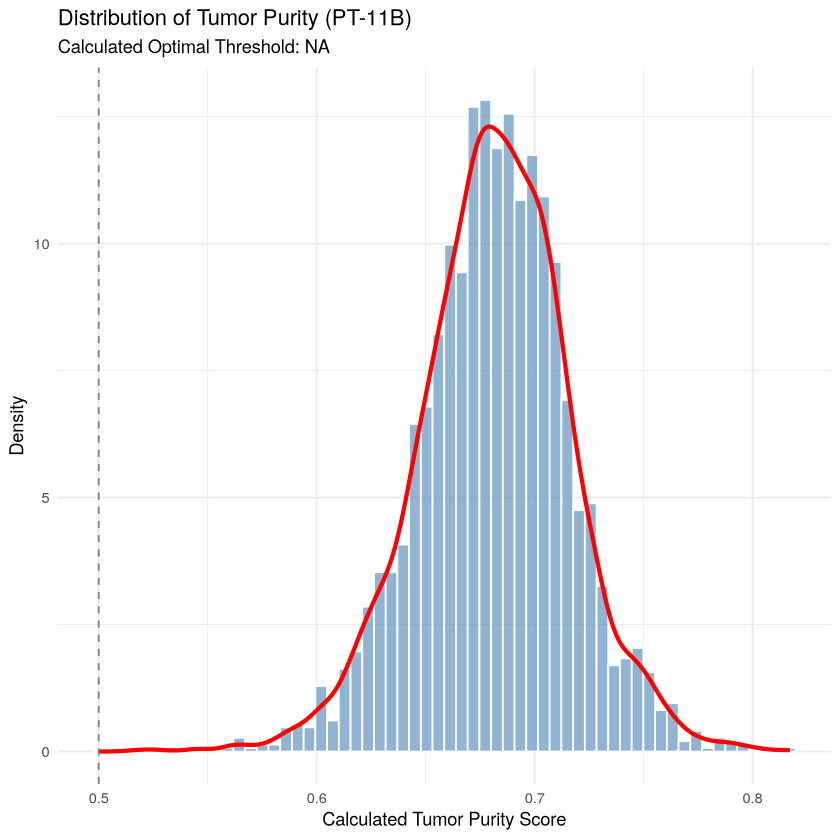

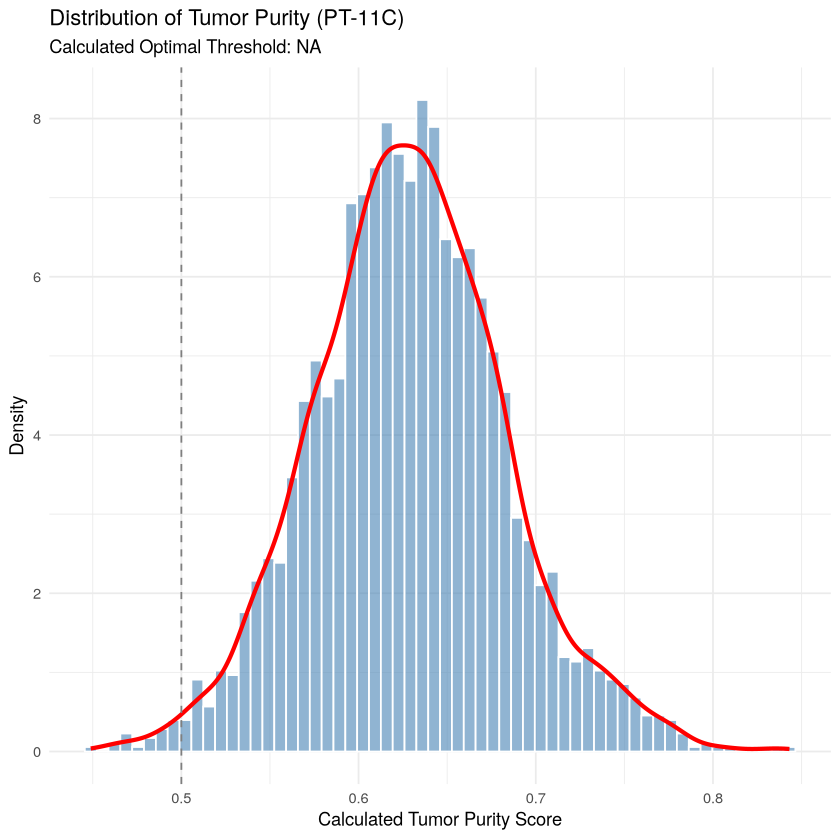

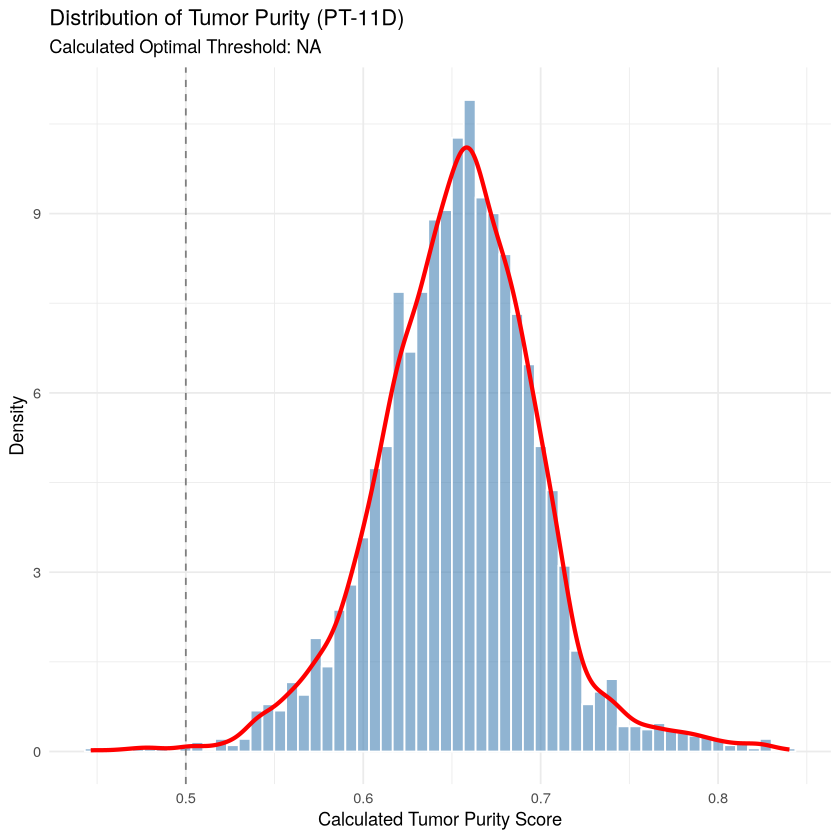

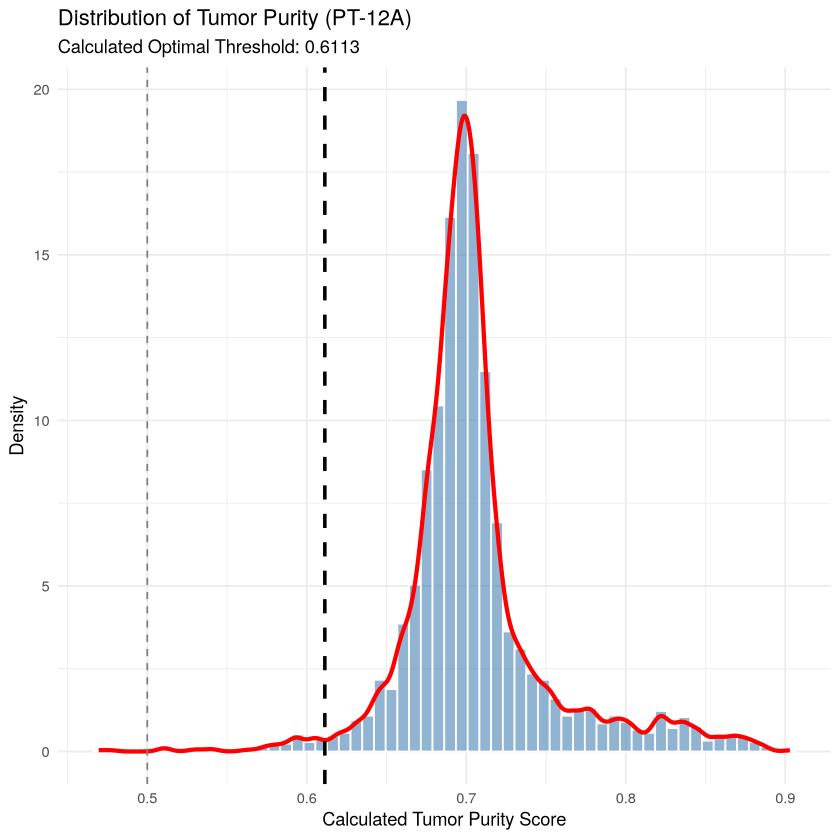

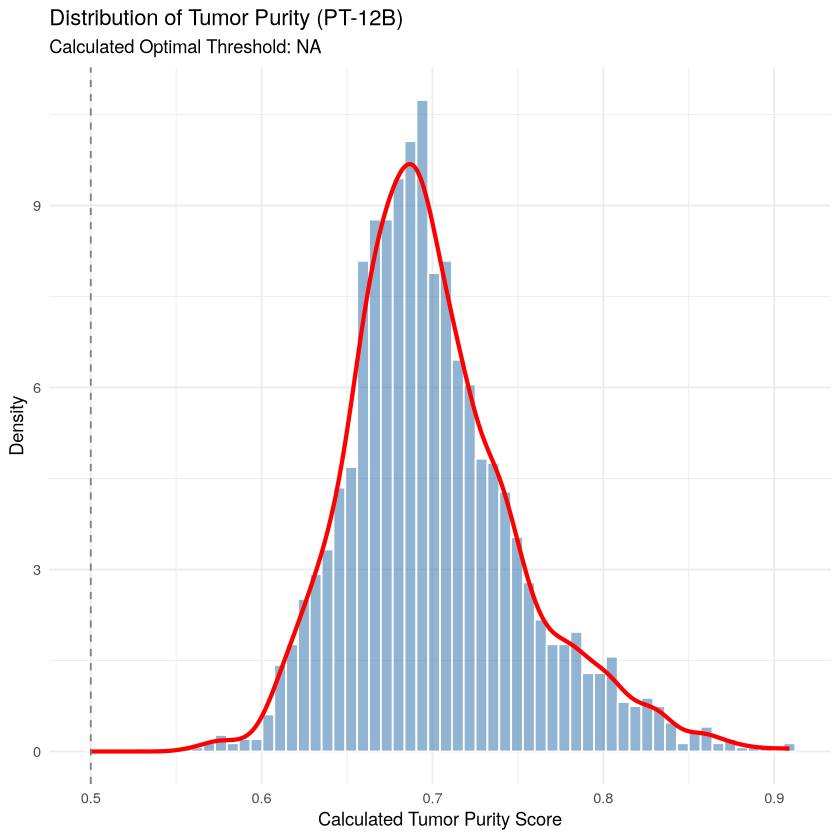

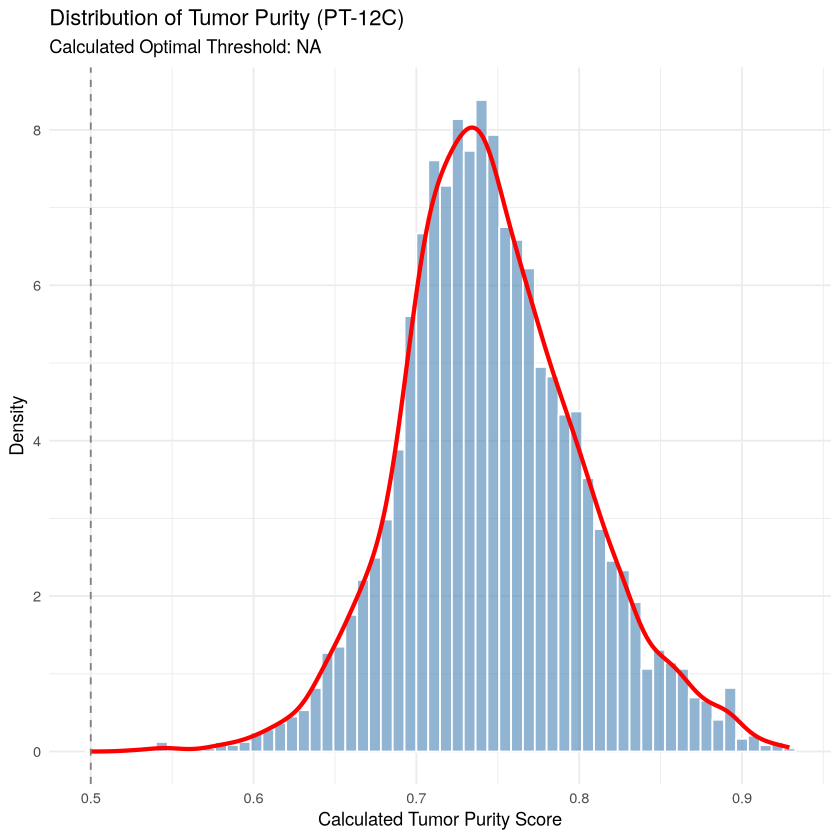

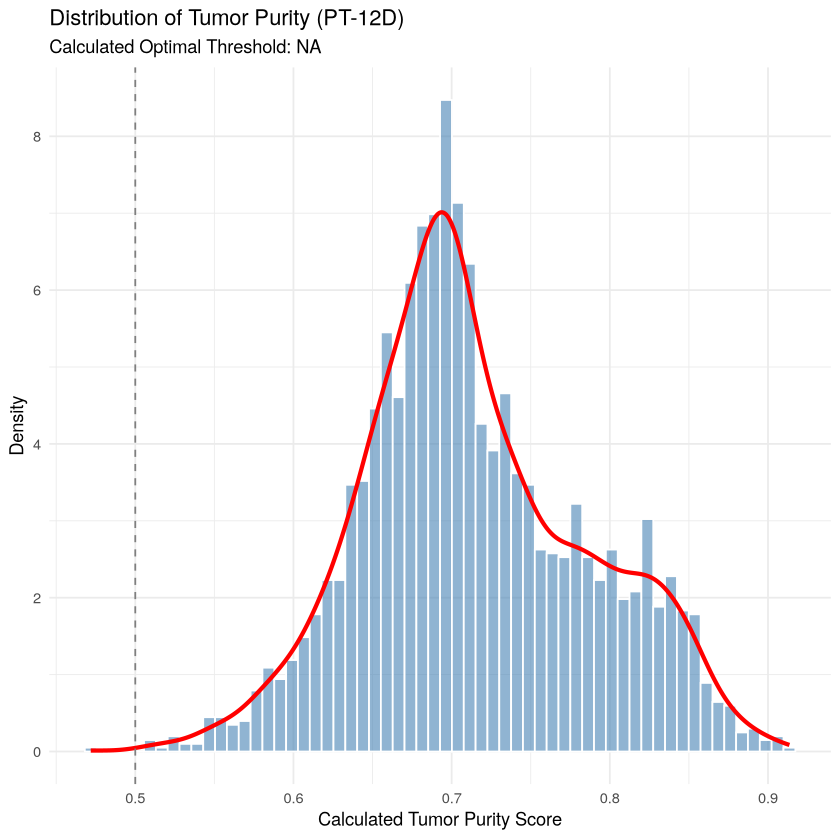

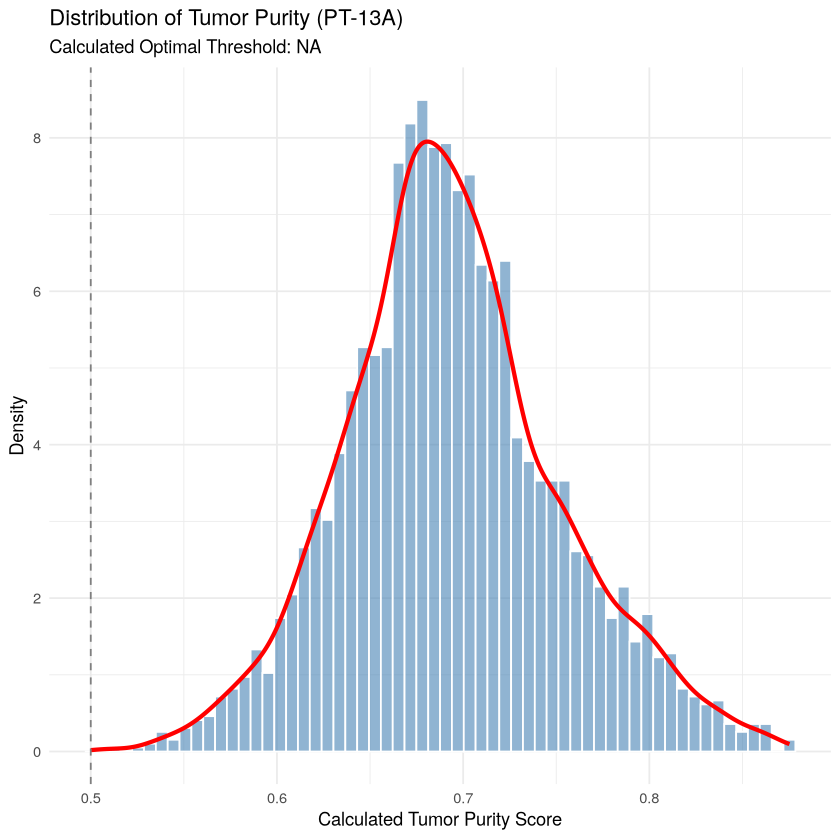

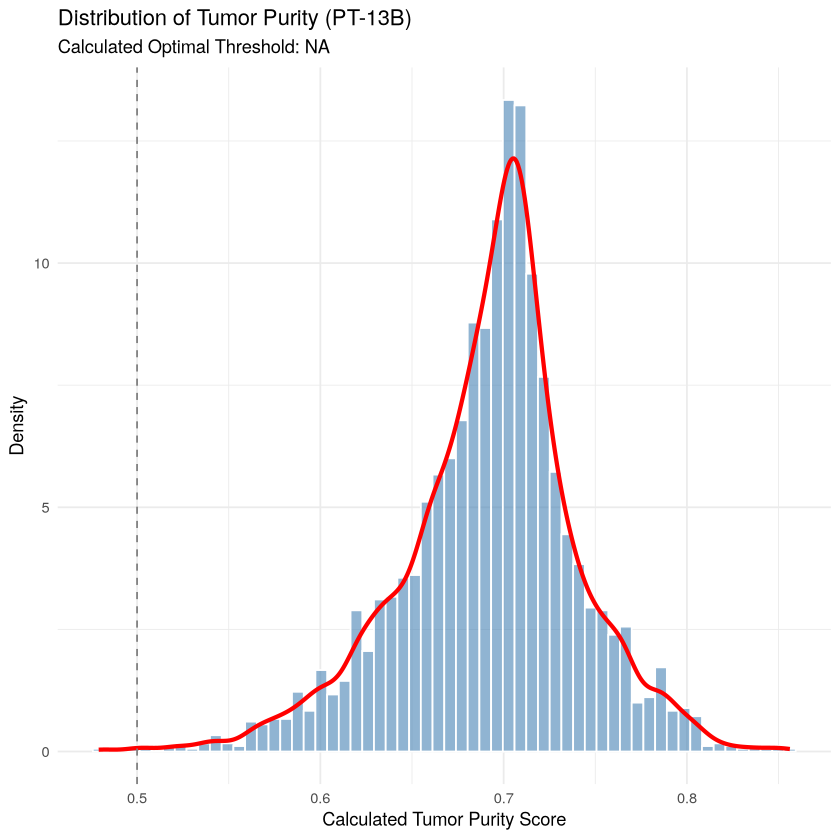

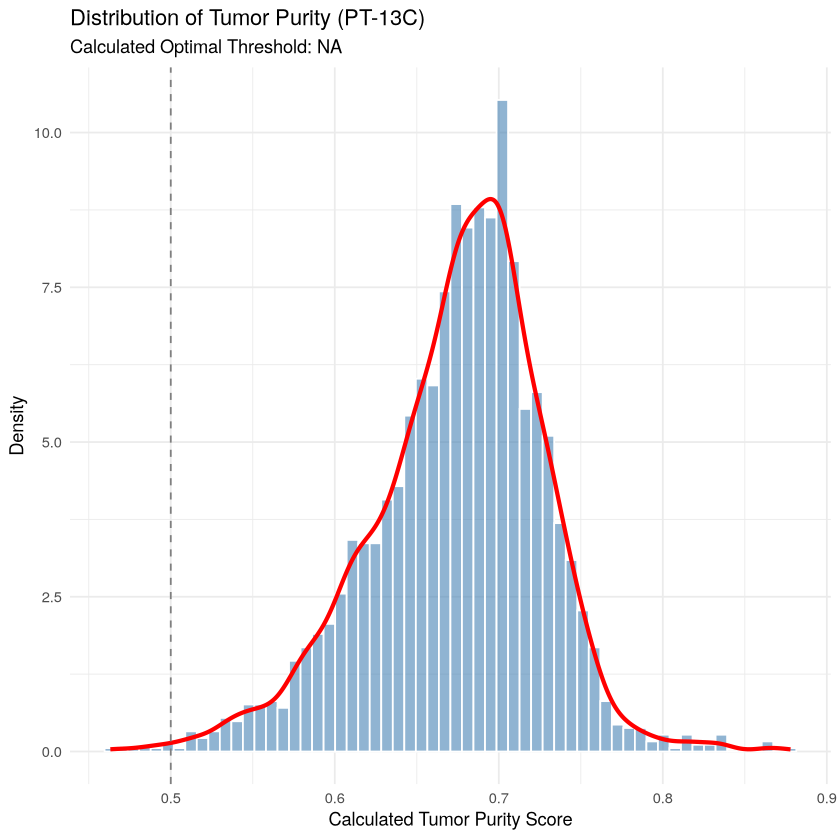

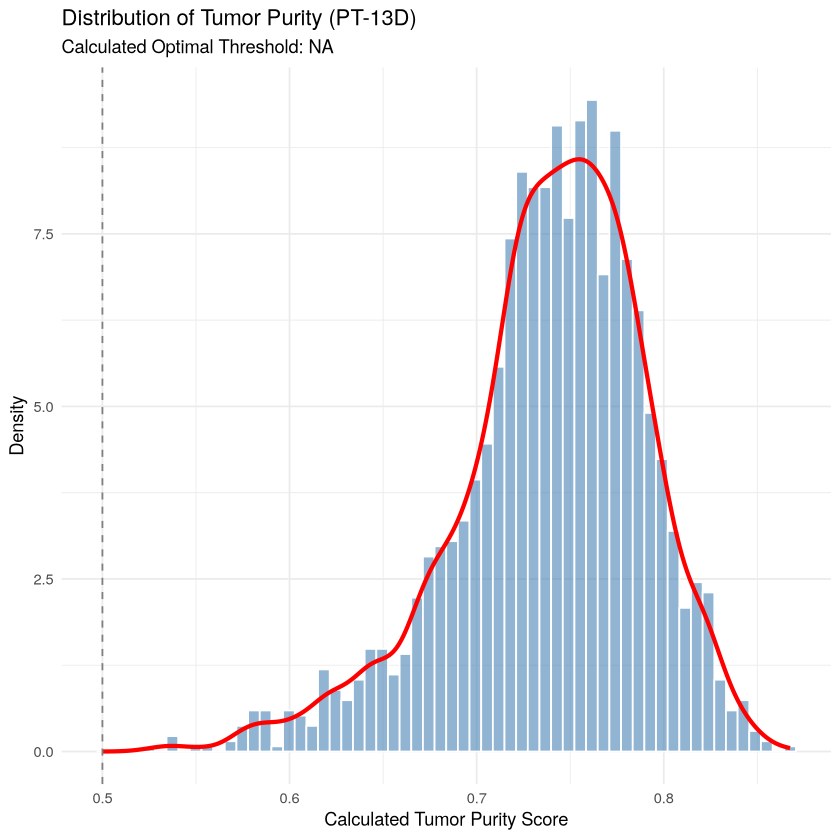

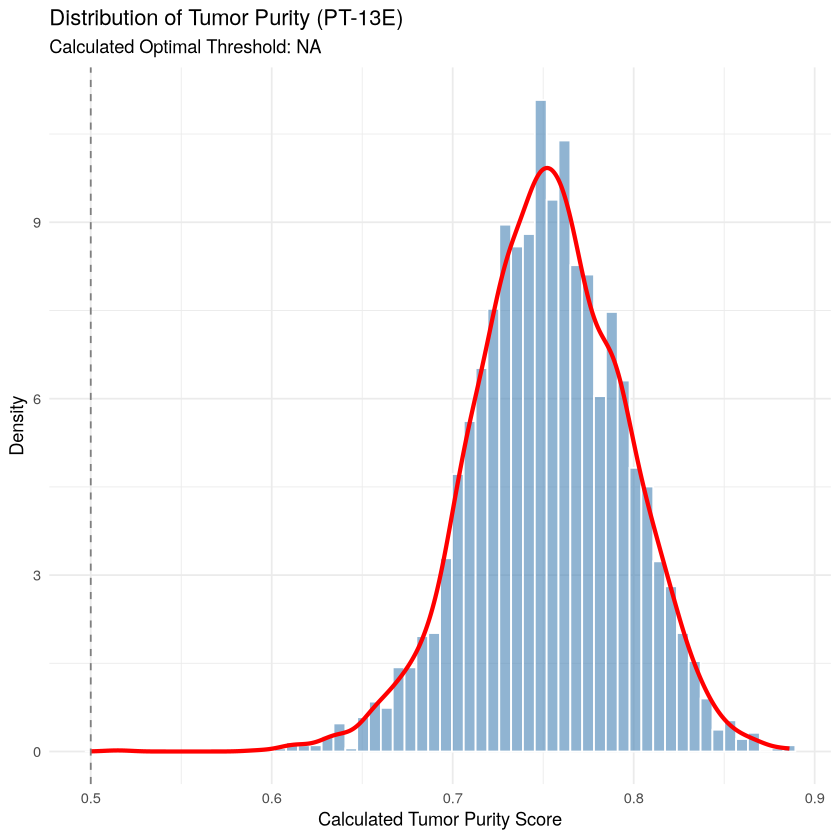

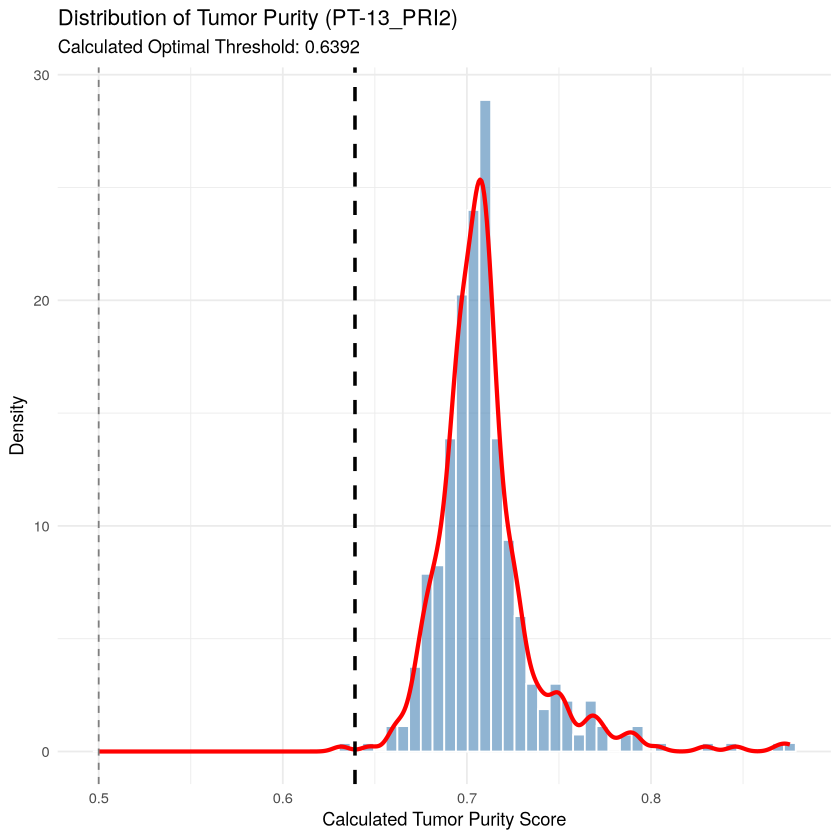

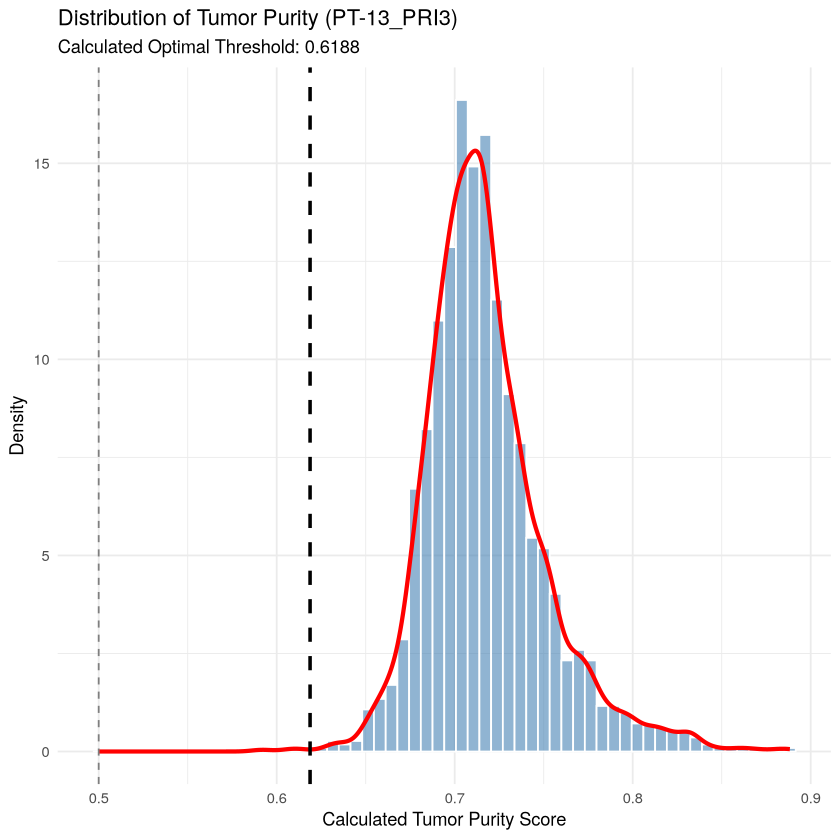

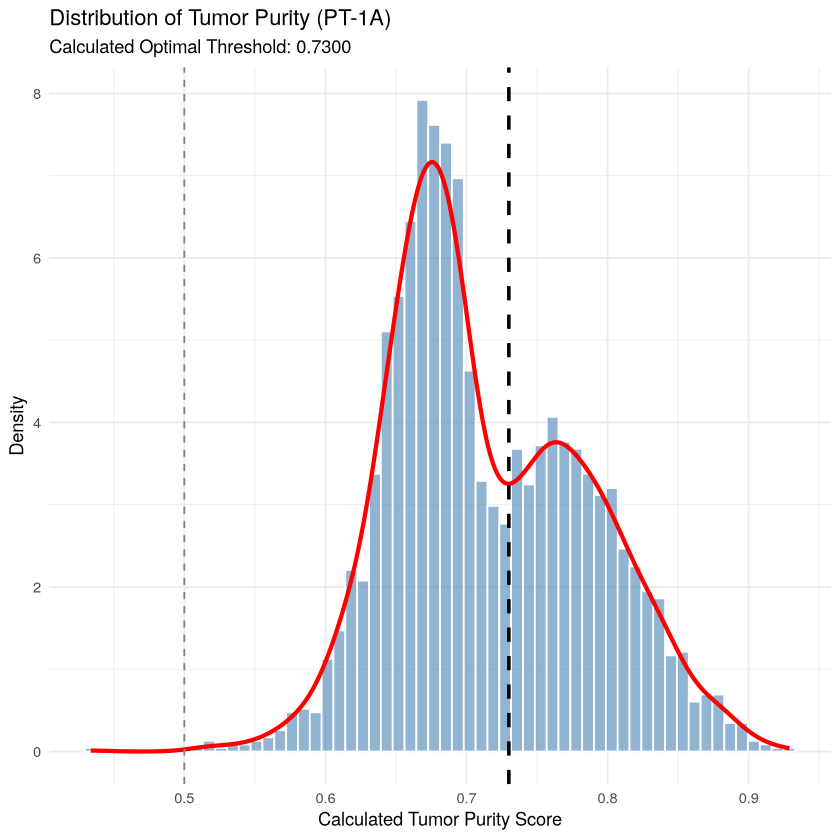

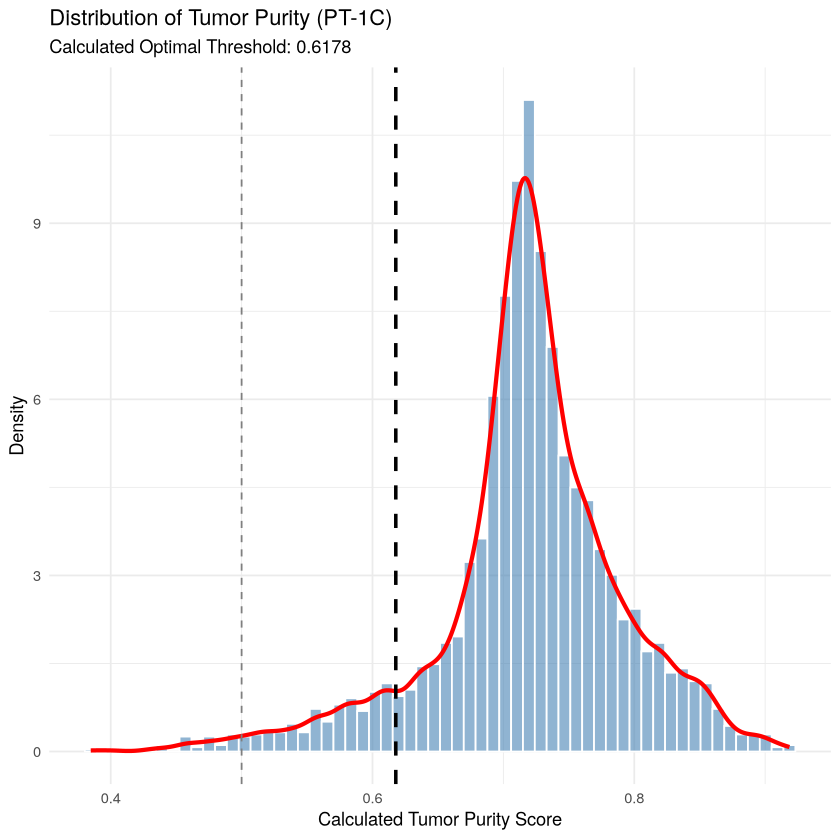

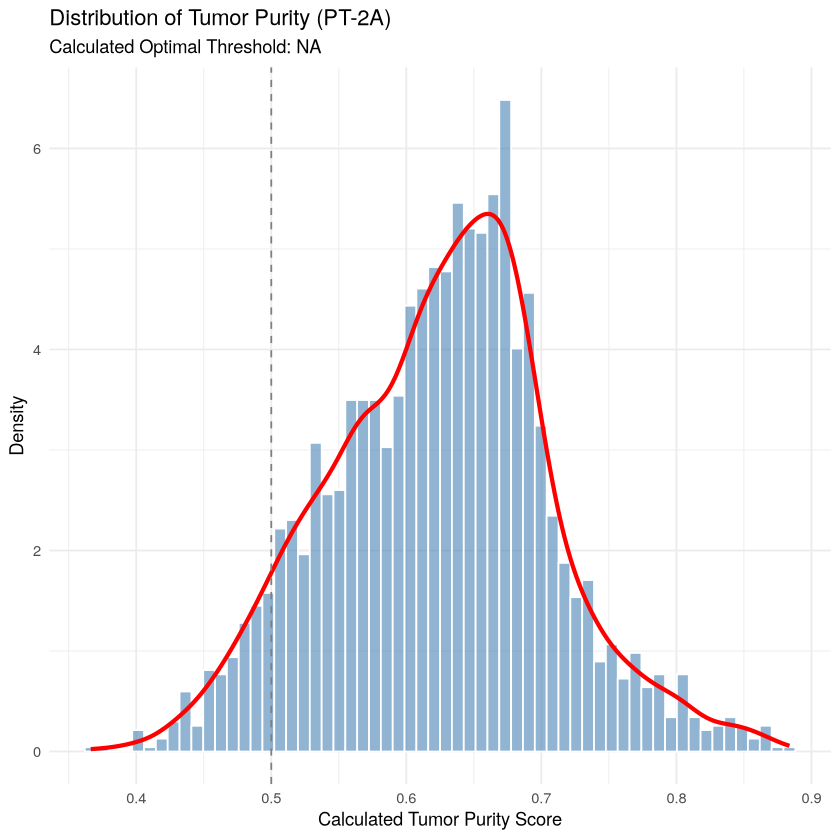

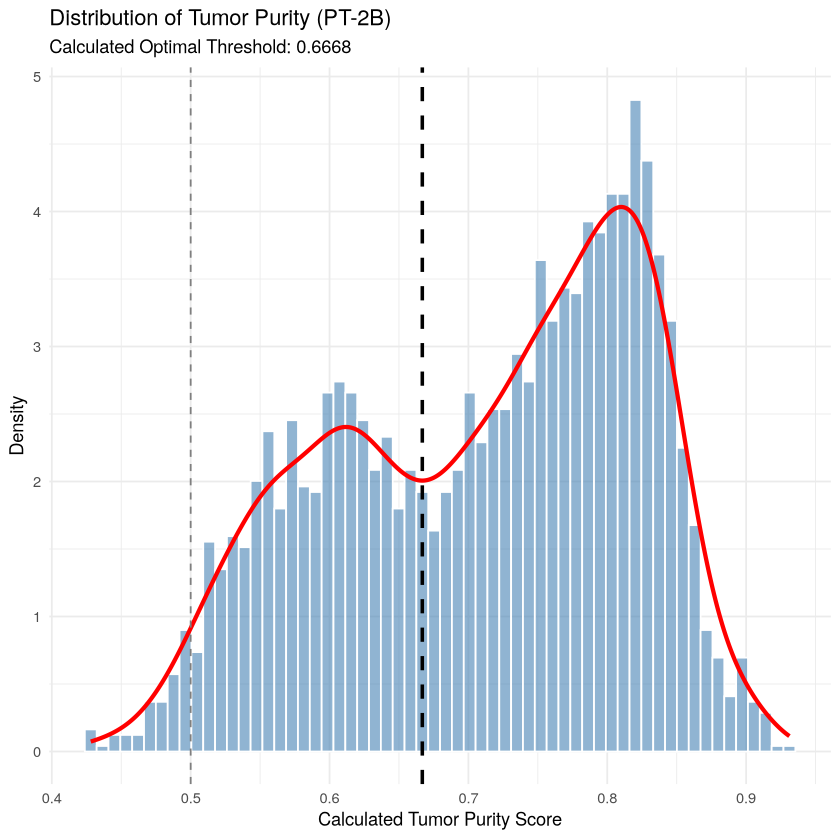

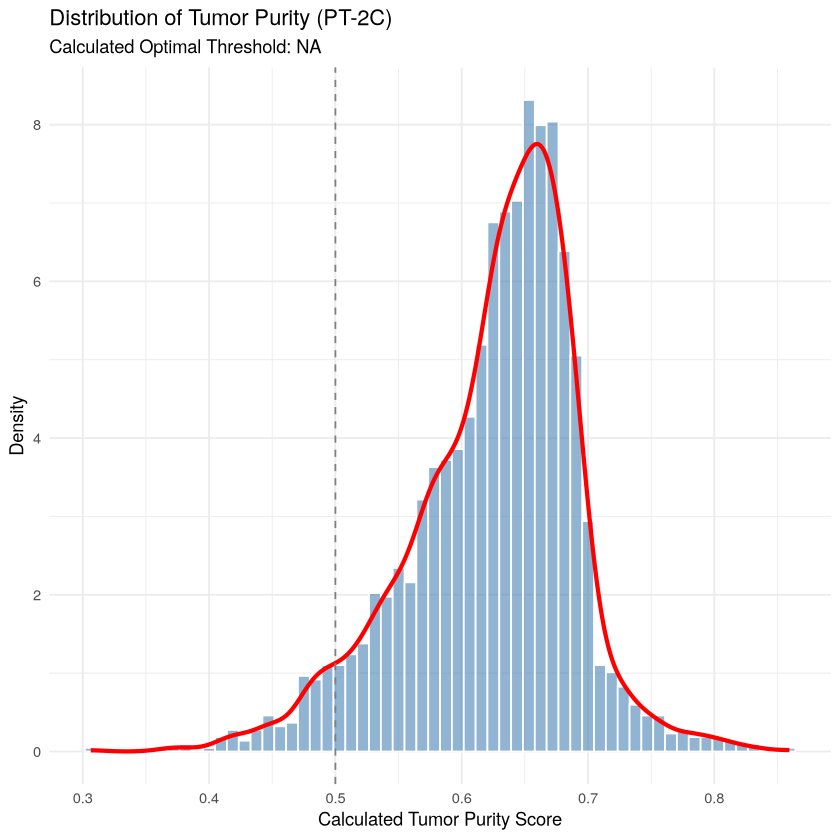

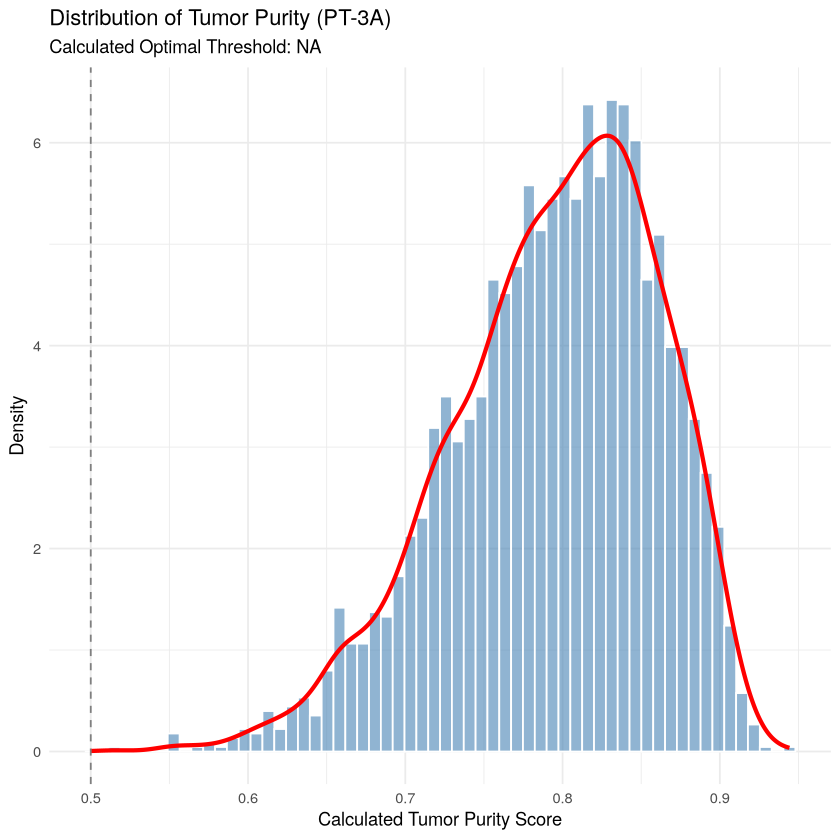

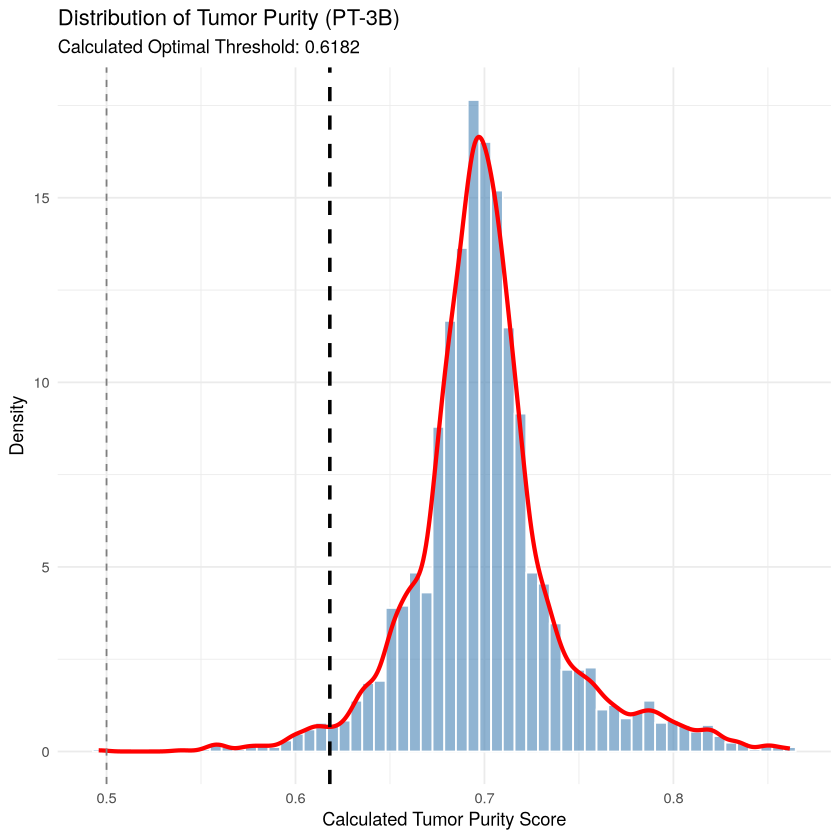

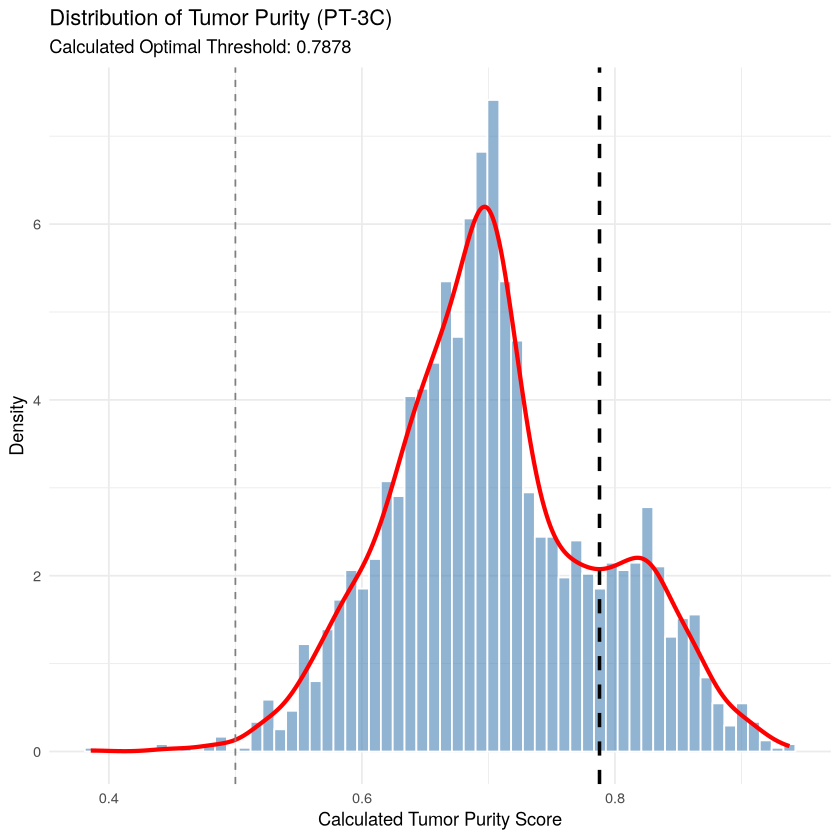

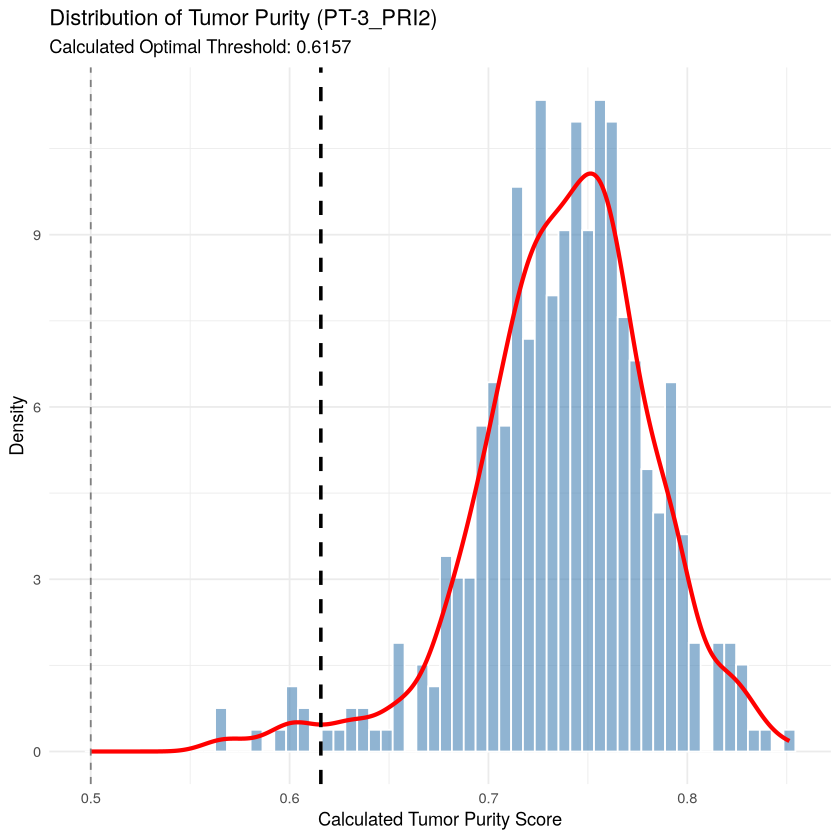

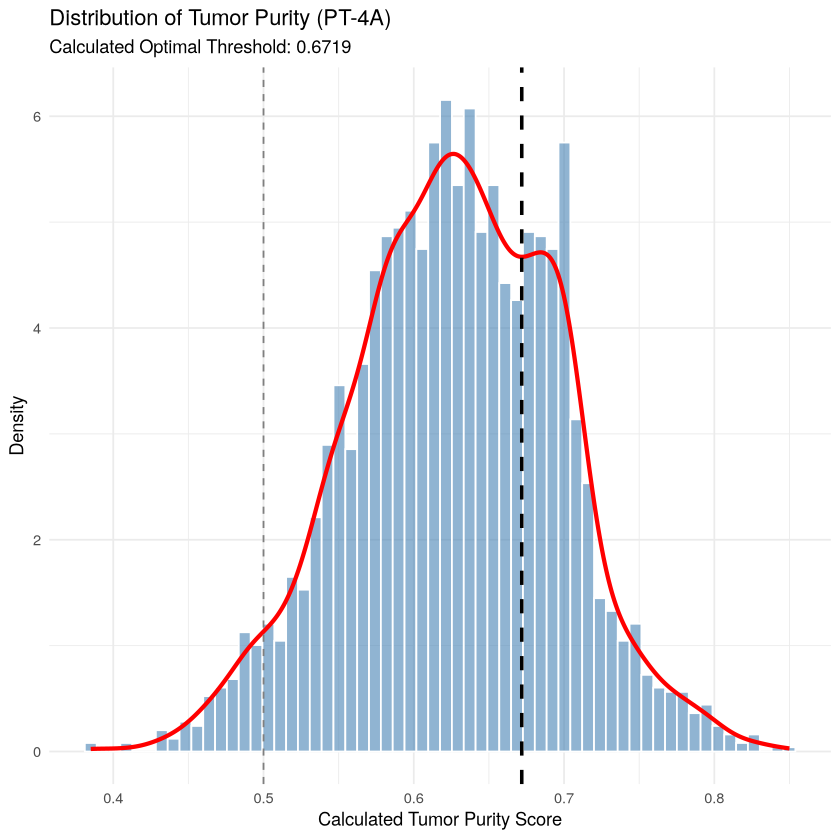

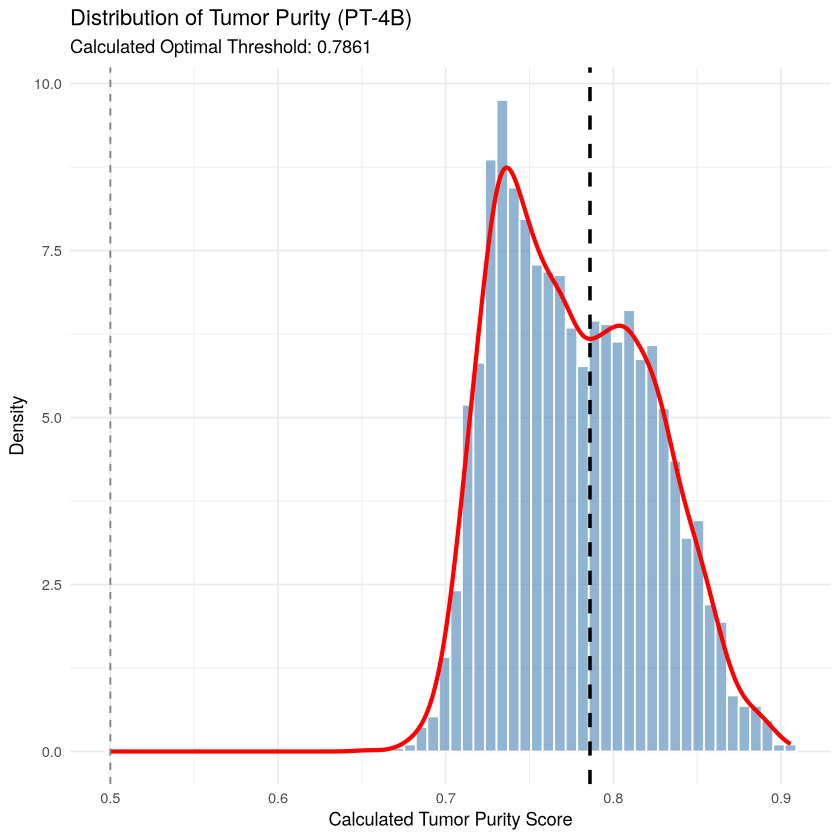

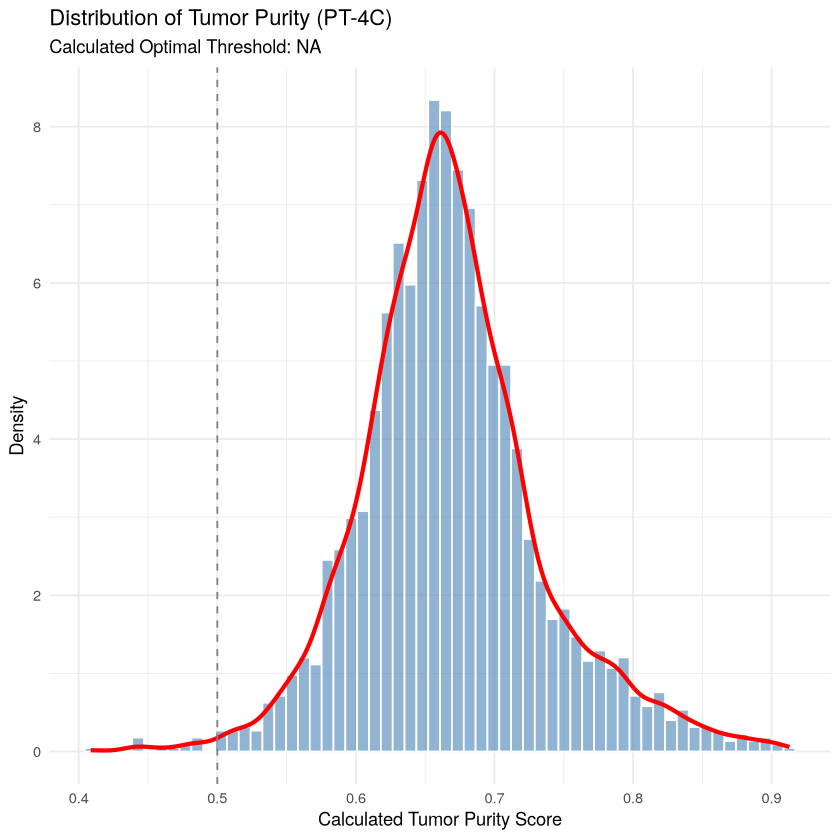

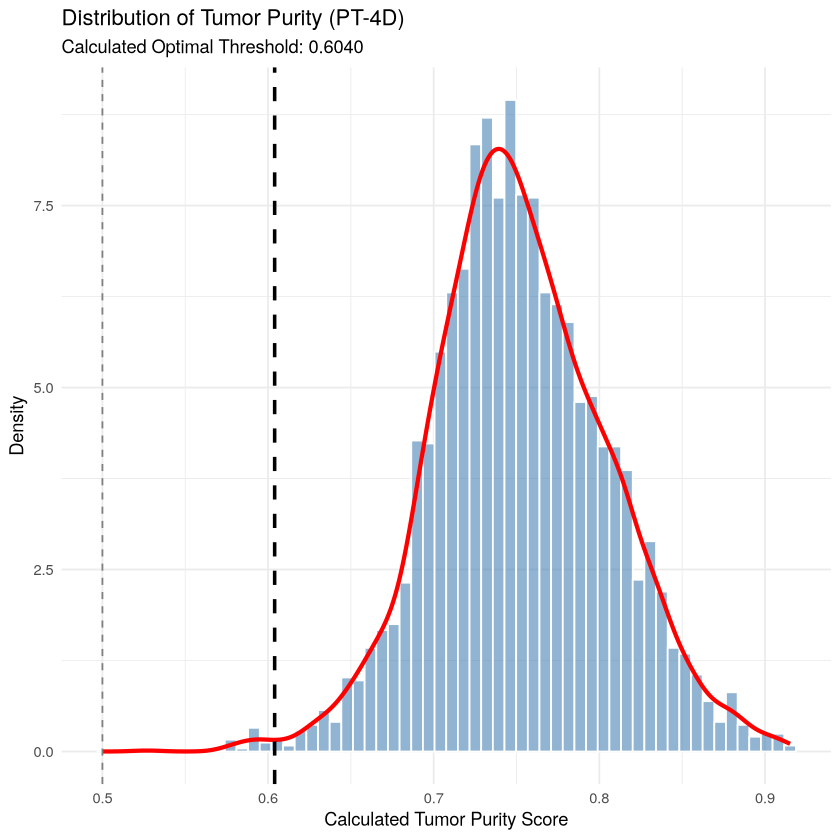

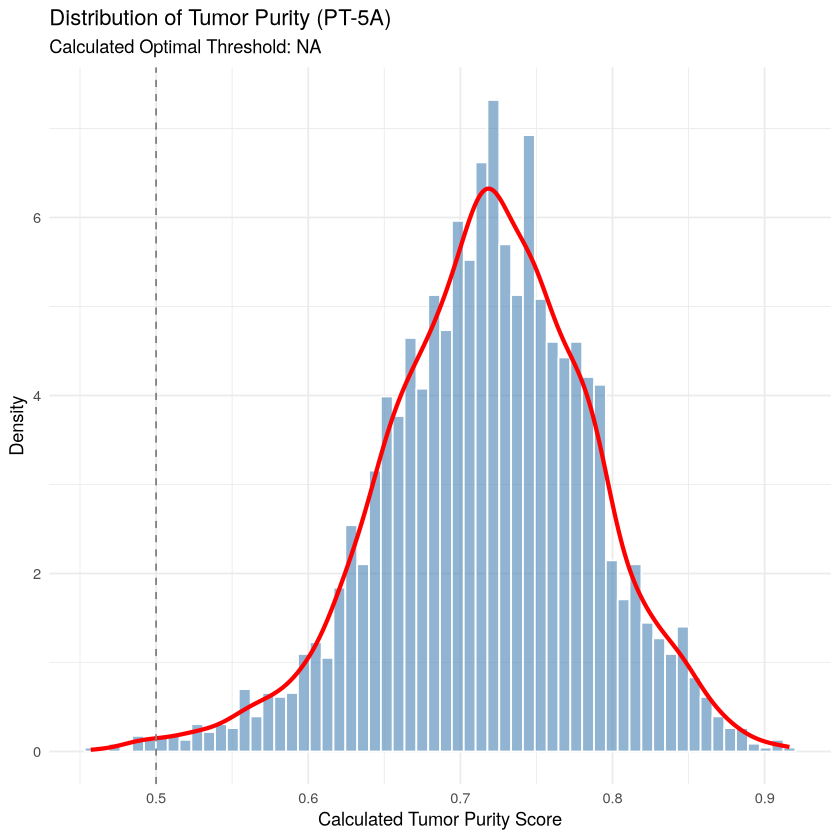

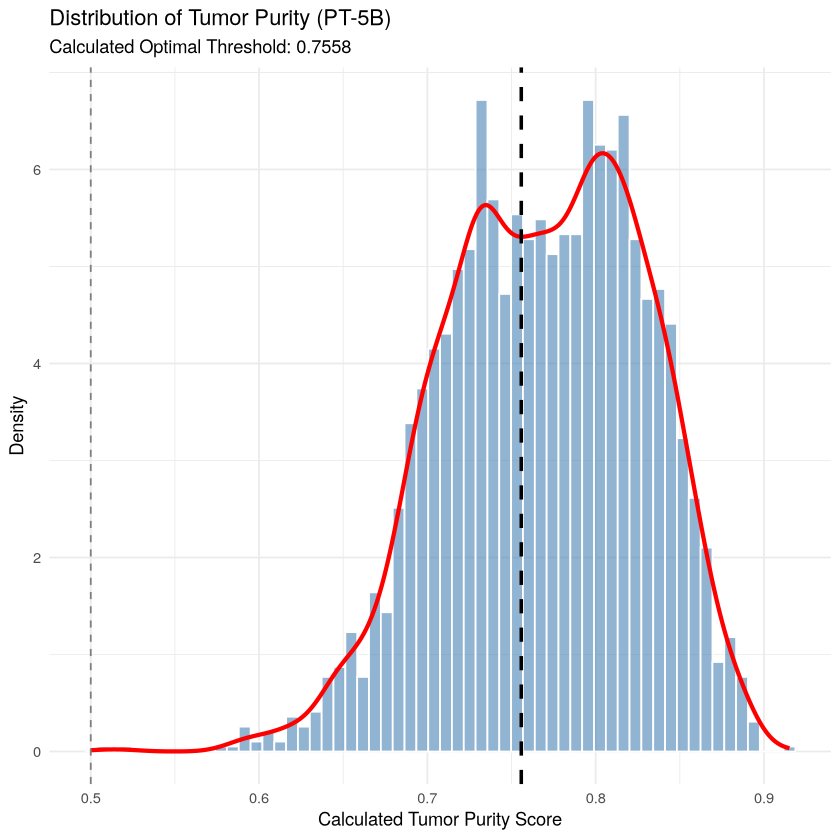

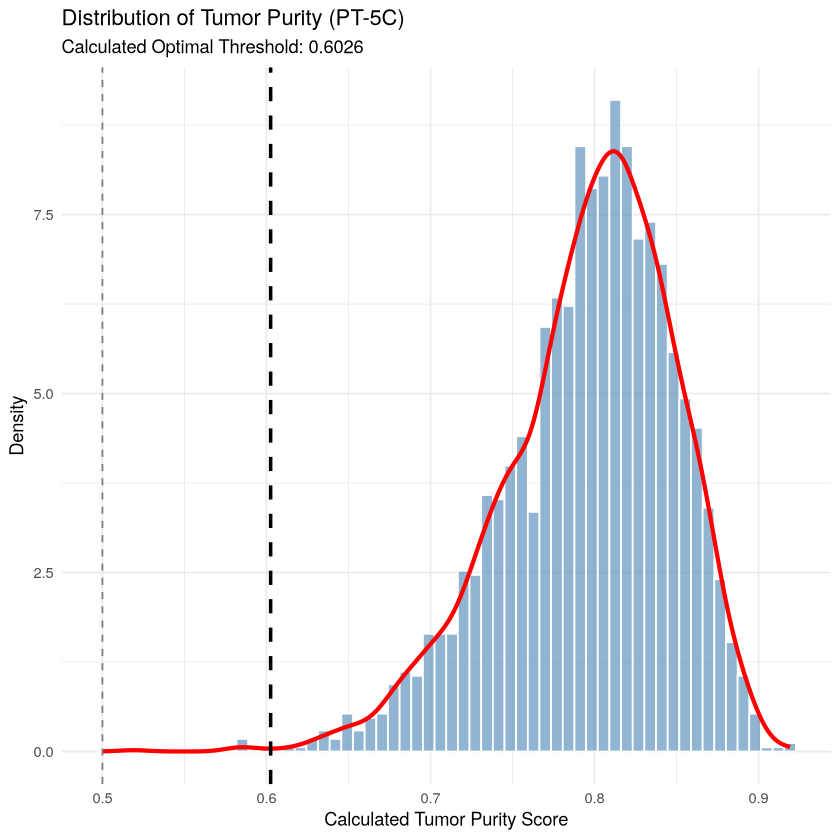

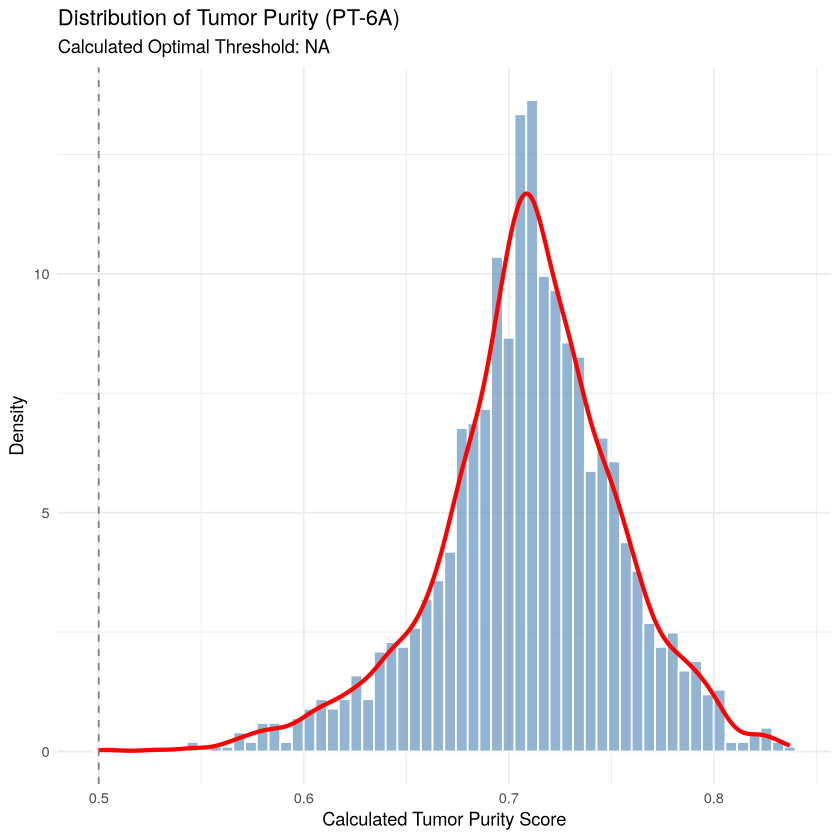

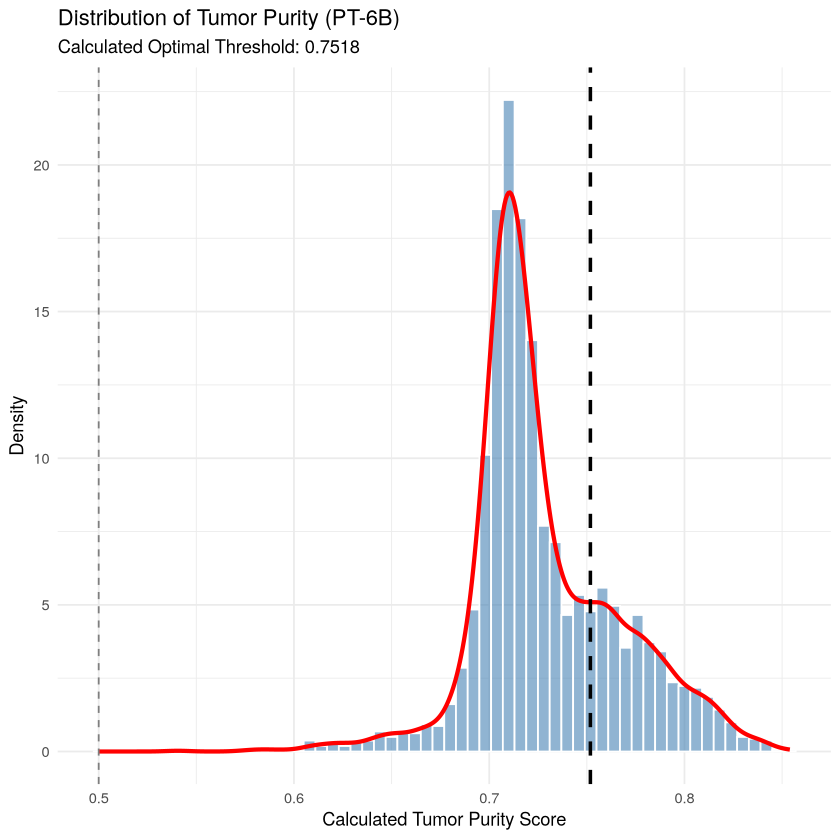

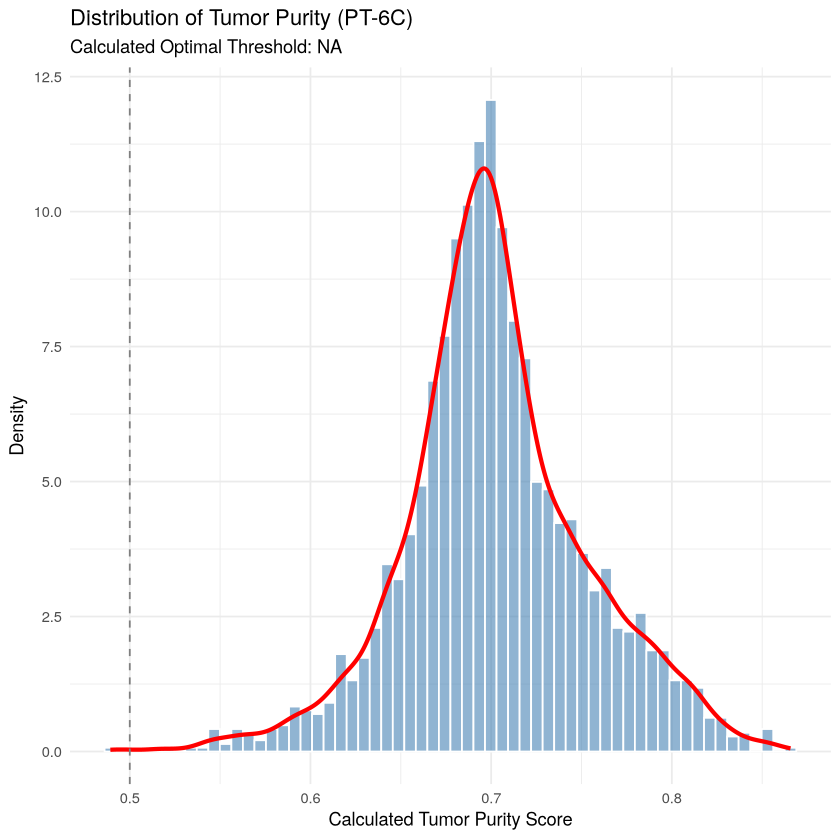

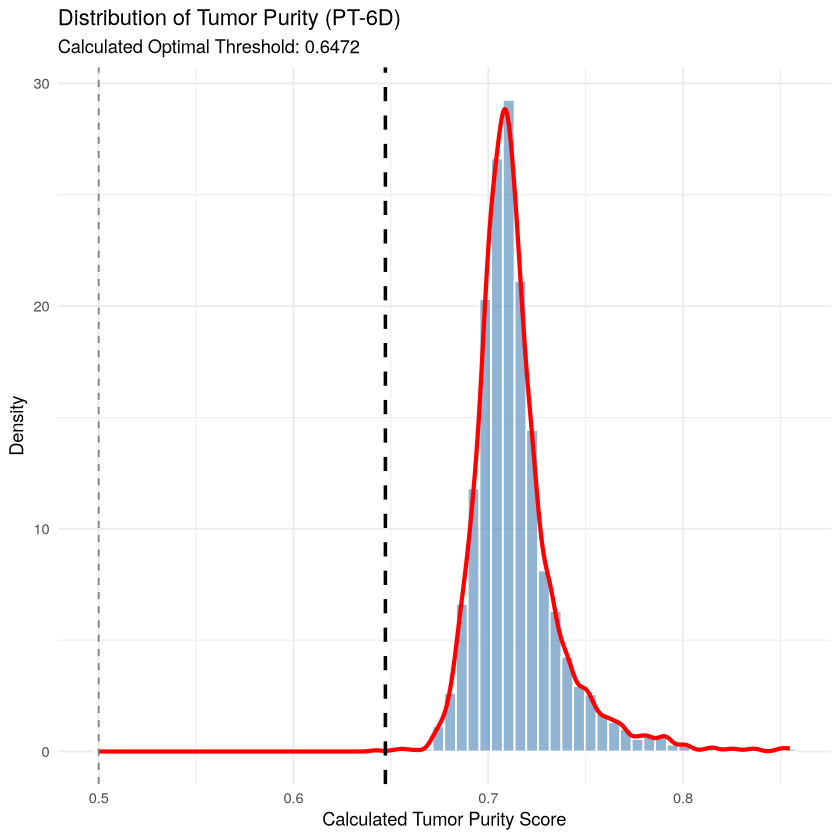

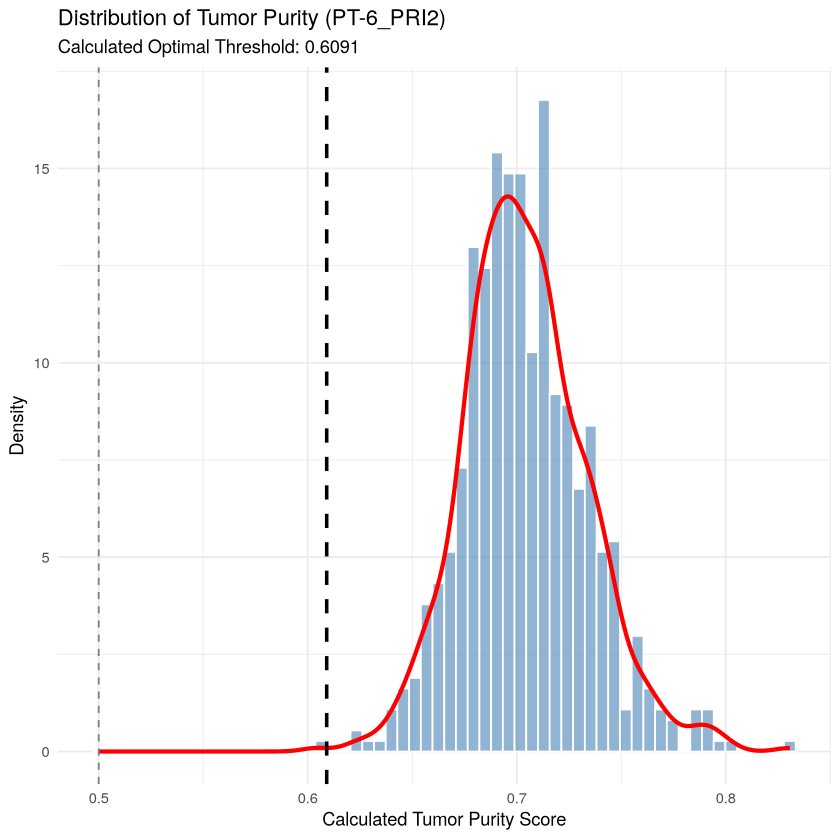

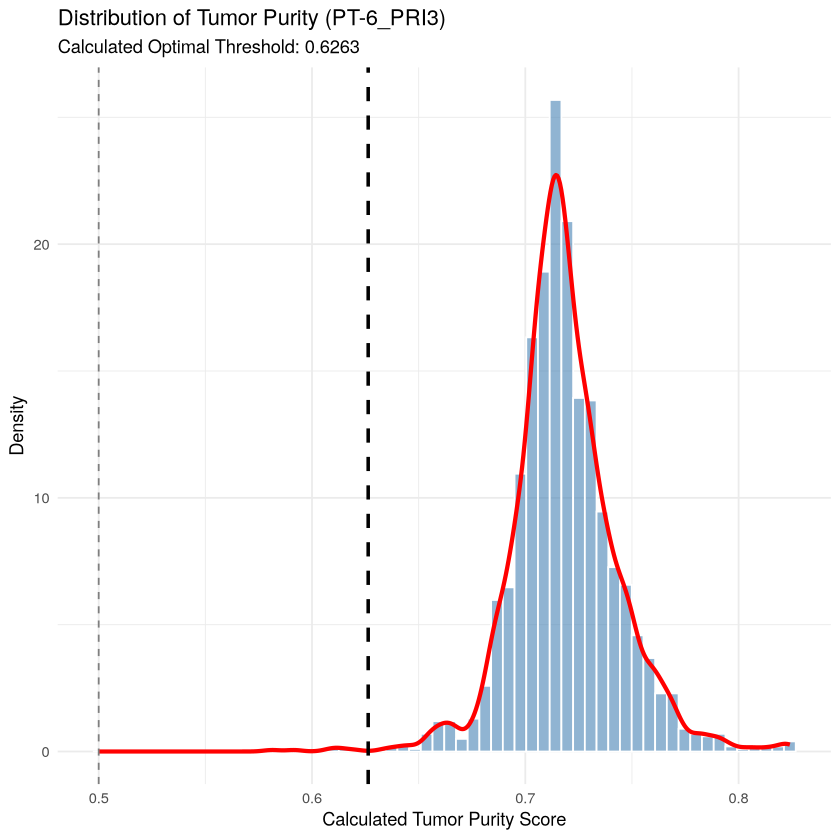

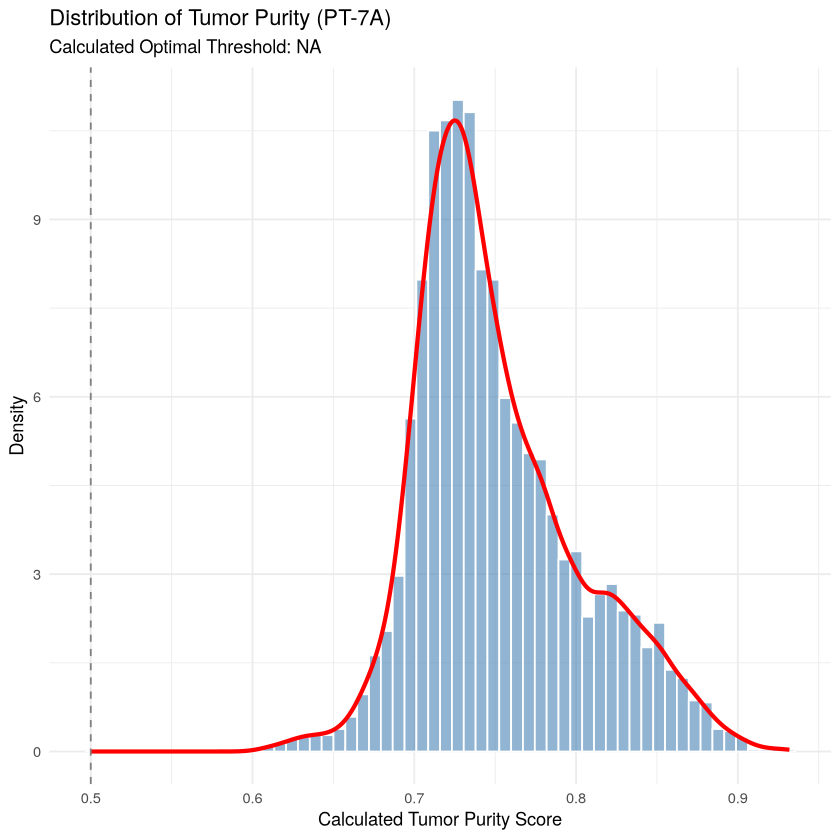

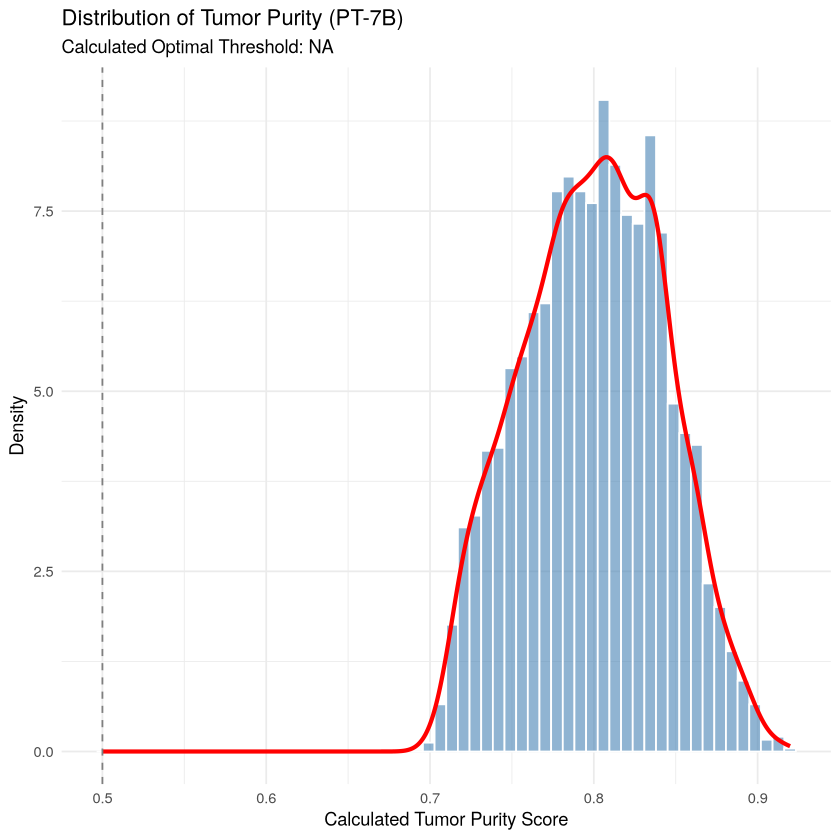

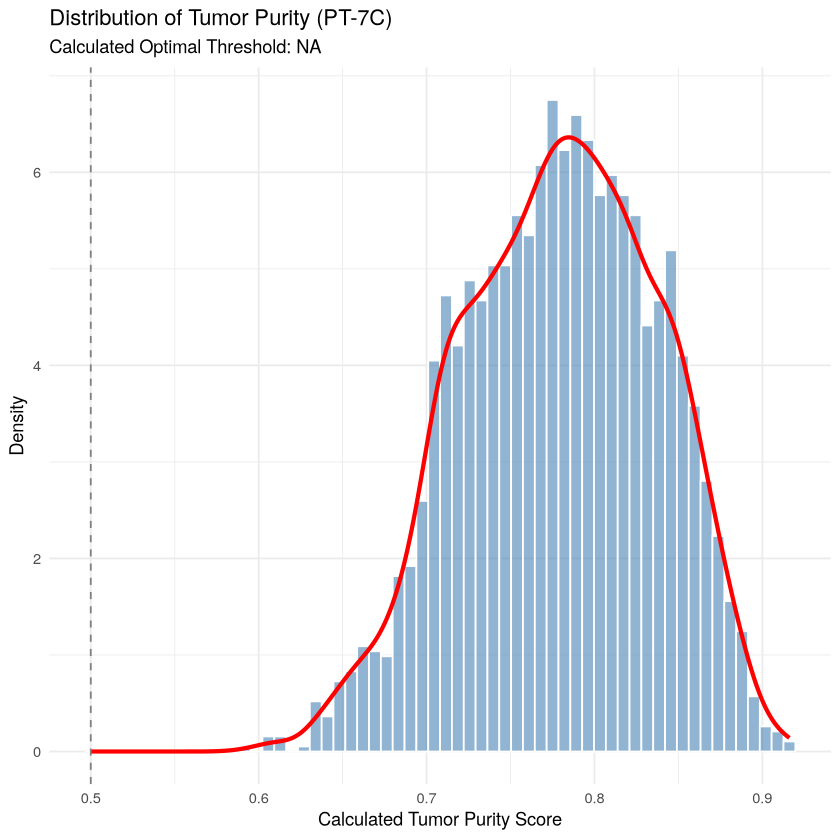

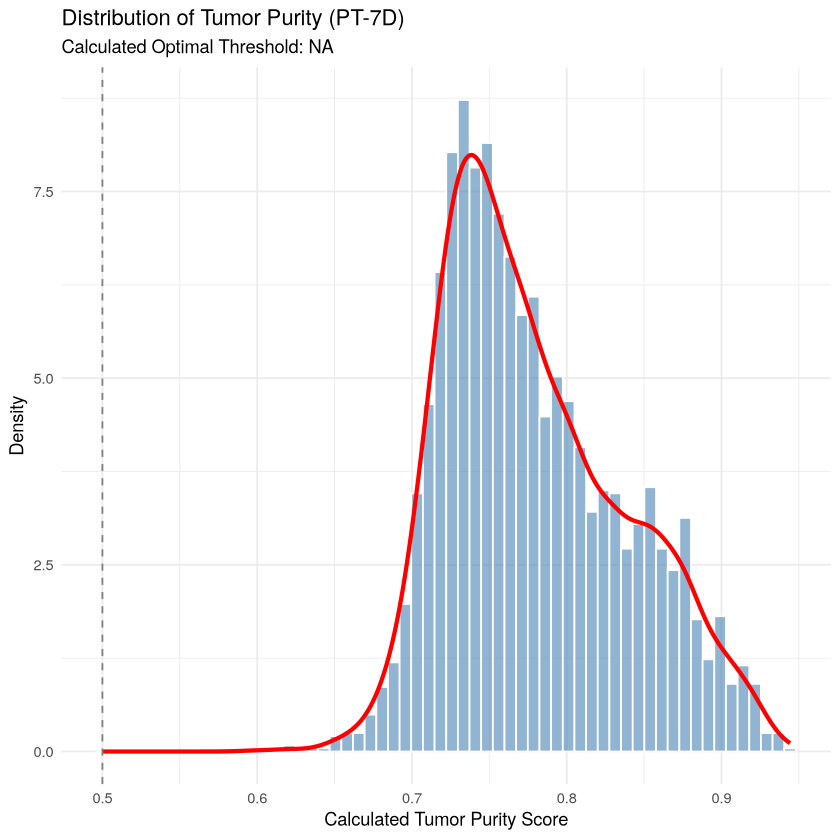

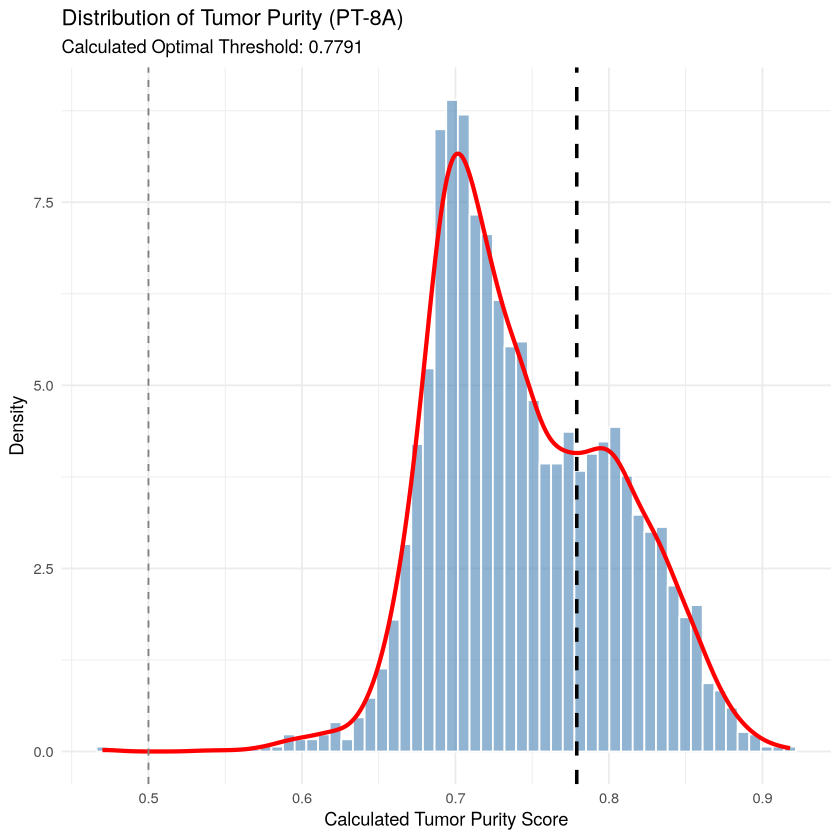

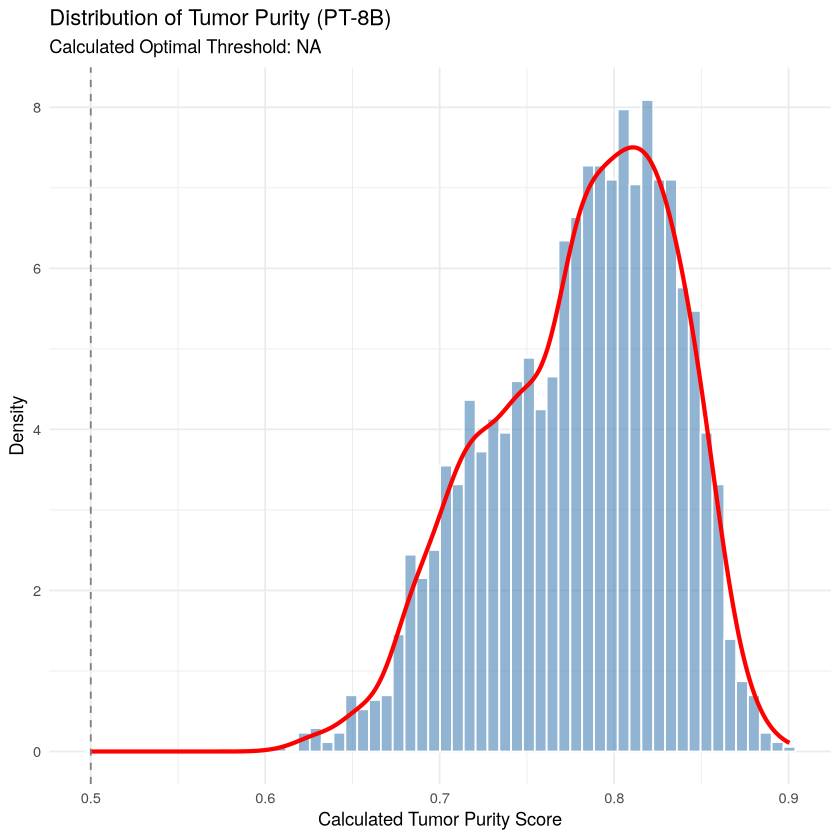

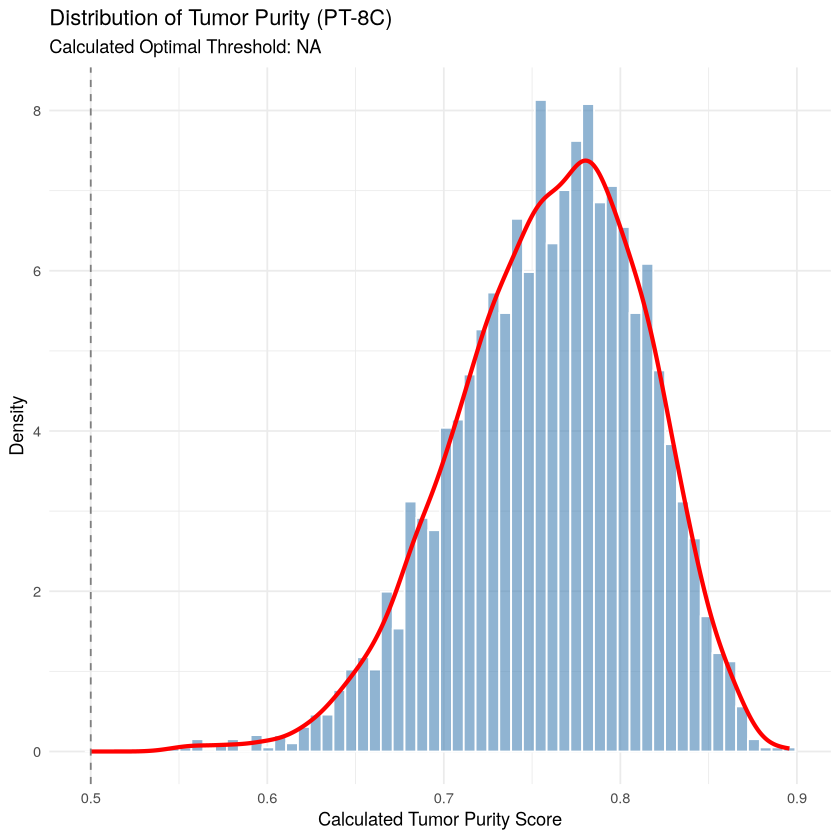

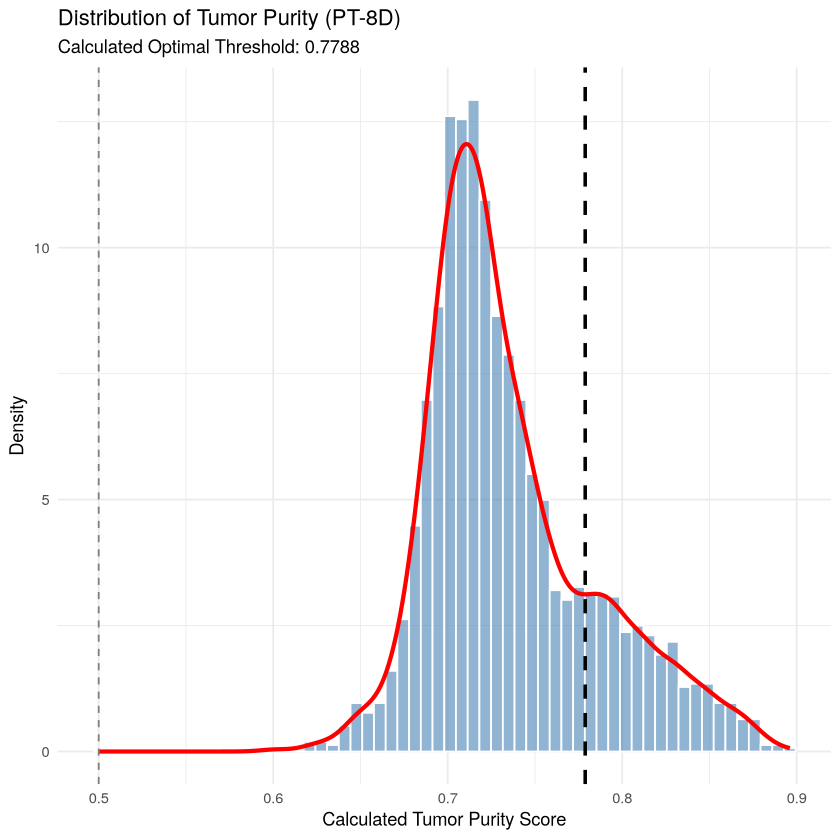

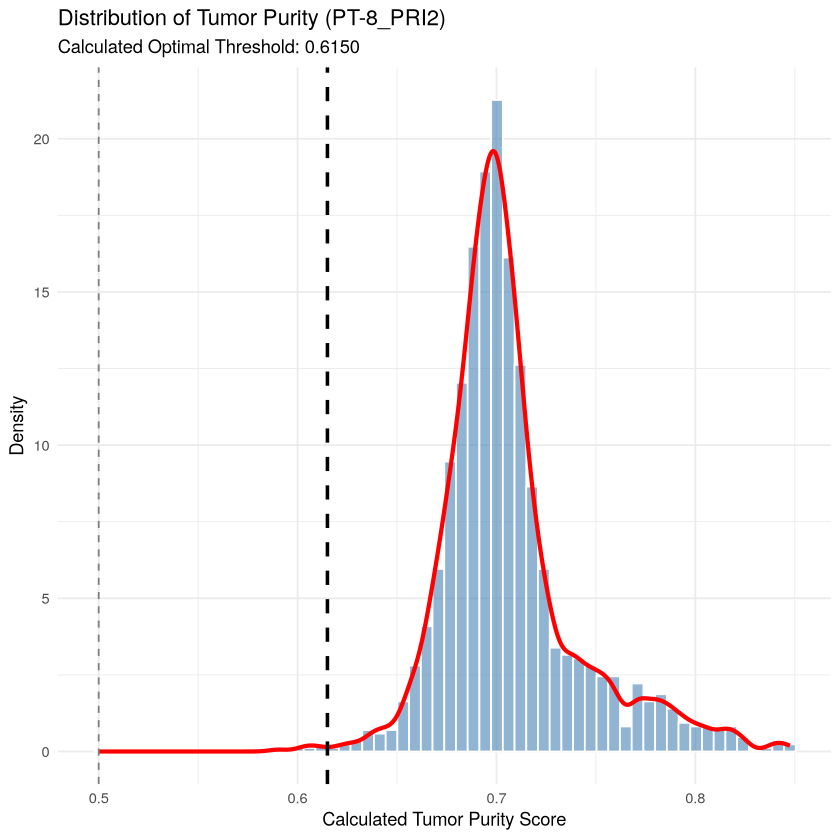

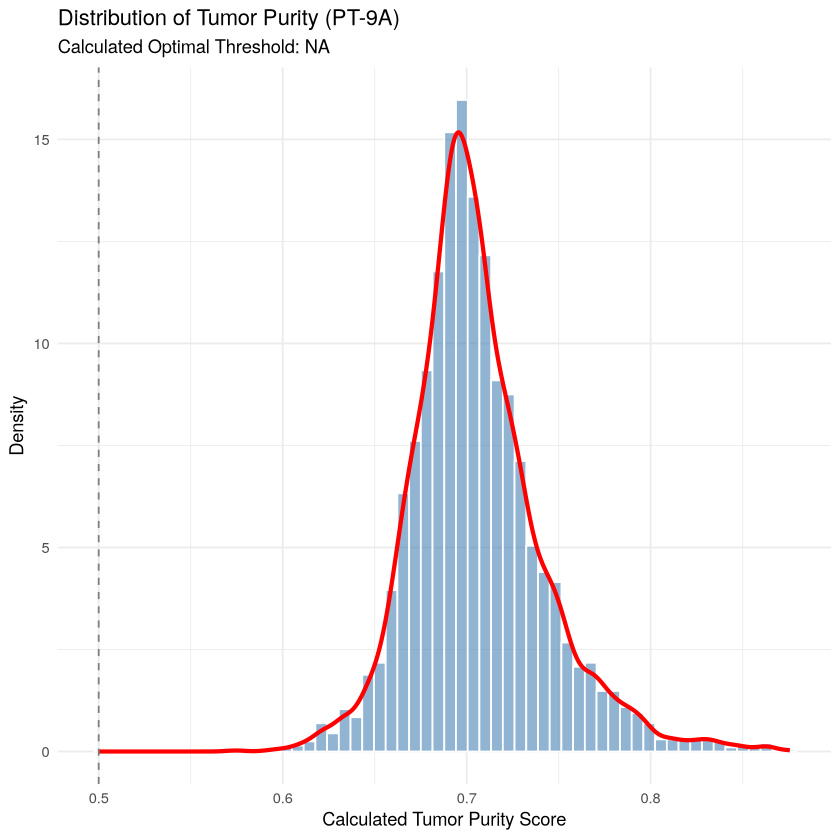

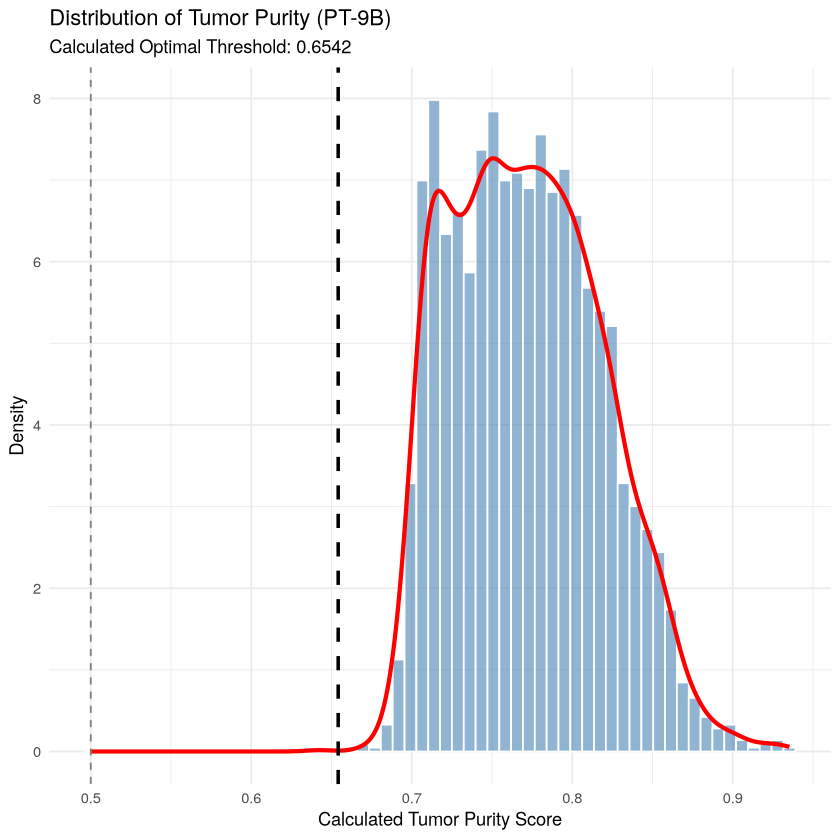

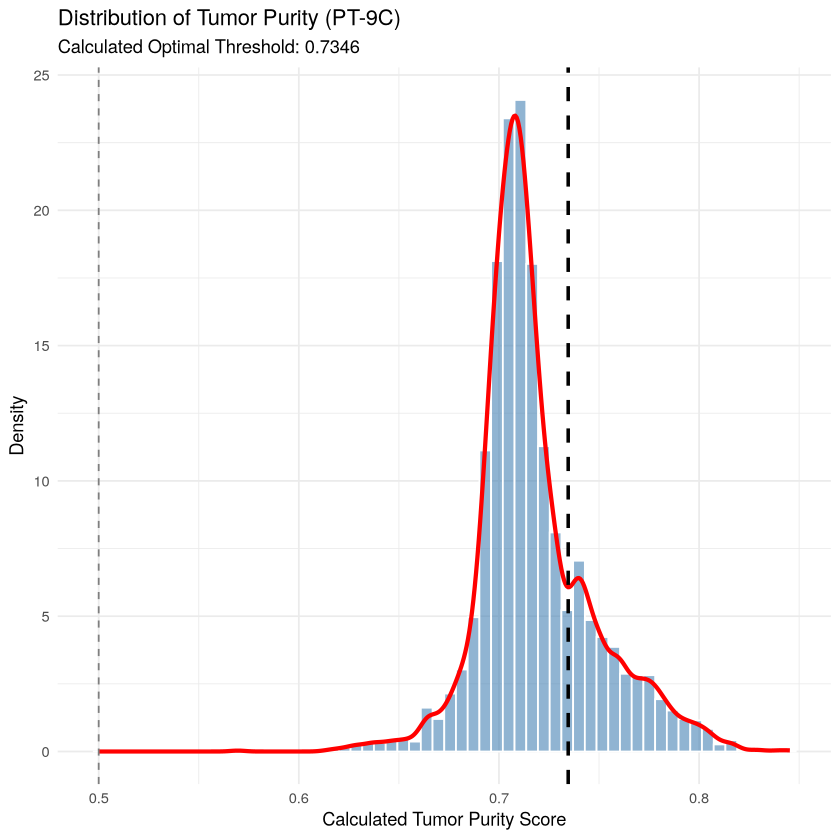

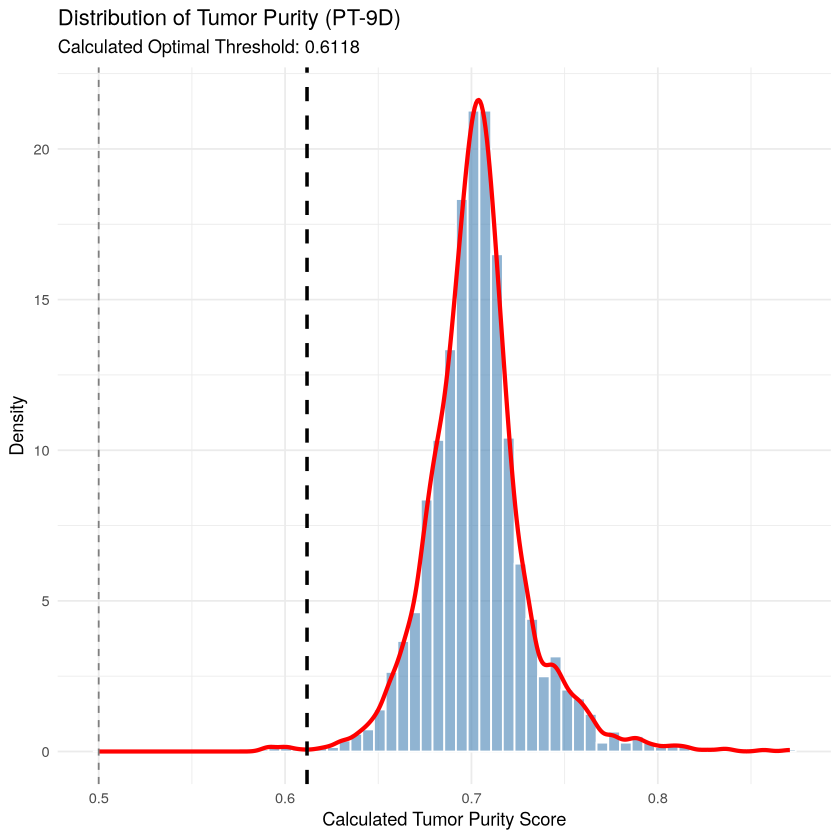

In [9]:
optimal_list <- c()

for (sample_id in sample_names) {
    # read sample's rds file
    base_dir <- "/scratch/hhuan40/Spatial-MetScore/data/processed/tumor_purity_estimate"
    rds_path <- file.path(base_dir, sample_id, paste0(sample_id, "_processed.rds"))
    seurat_obj <- readRDS(rds_path)

    # get the purity scores from the Seurat object
    purity_data <- seurat_obj@meta.data
    dens <- density(purity_data$TumorPurity)

    #get the new threshold
    valleys_idx <- which(diff(sign(diff(dens$y))) == 2)+1
    valley_x_all <- dens$x[valleys_idx]
    optimal_threshold <- valley_x_all[valley_x_all > 0.60 & valley_x_all < 0.80]

    # some samples might not have a threshold
    if (length(optimal_threshold) == 0) {
        optimal_threshold <- NA 
    } else {
        optimal_threshold <- optimal_threshold[1] 
    }
    
    optimal_list[sample_id] <- optimal_threshold
    
    # draw the histogram and density curve
    p <- ggplot(purity_data, aes(x = TumorPurity)) +
        # set y as the density
      geom_histogram(aes(y = ..density..), bins = 60, fill = "steelblue", alpha = 0.6, color = "white") +
      # density curve
      geom_density(color = "red", linewidth = 1.2) +
      theme_minimal() +
      labs(title = sprintf("Distribution of Tumor Purity (%s)", sample_id),
           subtitle = sprintf("Calculated Optimal Threshold: %.4f", optimal_threshold),
           x = "Calculated Tumor Purity Score",
           y = "Density") +
      # threshold lines
      geom_vline(xintercept = 0.5, linetype = "dashed", color = "gray50") 
      if (!is.na(optimal_threshold)) {
        p <- p + geom_vline(xintercept = optimal_threshold, linetype = "dashed", color = "black", linewidth = 1)
      }


    # print the plot
    print(p)
    plot_out_path <- file.path(base_dir, sample_id, paste0(sample_id, "_purity_histogram.png"))
    ggsave(plot_out_path, plot = p, width = 8, height = 6)
}

In [10]:
print(optimal_list)

    PT-10A     PT-10B     PT-10C     PT-10D     PT-11A     PT-11B     PT-11C 
        NA  0.6180443         NA  0.6282602         NA         NA         NA 
    PT-11D     PT-12A     PT-12B     PT-12C     PT-12D     PT-13A     PT-13B 
        NA  0.6113312         NA         NA         NA         NA         NA 
    PT-13C     PT-13D     PT-13E PT-13_PRI2 PT-13_PRI3      PT-1A      PT-1C 
        NA         NA         NA  0.6392121  0.6187543  0.7300326  0.6177981 
     PT-2A      PT-2B      PT-2C      PT-3A      PT-3B      PT-3C  PT-3_PRI2 
        NA  0.6668060         NA         NA  0.6181658  0.7877978  0.6157080 
     PT-4A      PT-4B      PT-4C      PT-4D      PT-5A      PT-5B      PT-5C 
 0.6718532  0.7860851         NA  0.6039894         NA  0.7558103  0.6025502 
     PT-6A      PT-6B      PT-6C      PT-6D  PT-6_PRI2  PT-6_PRI3      PT-7A 
        NA  0.7518098         NA  0.6471918  0.6090810  0.6263464         NA 
     PT-7B      PT-7C      PT-7D      PT-8A      PT-8B      PT-8

In [ ]:
help(package="estimate")